# 🎨 Week 3: The Expressive Power of Graph Neural Networks

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W3/Sample_Code_3.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Overview

In Week 2 we built GNNs out of **message passing** and saw that they *work*. This week we ask a sharper
question:

> **What can a GNN actually tell apart — and what is it blind to?**

This is the question of **expressive power**. A GNN that cannot distinguish two graphs must, by
definition, give them the same prediction. So the limits of expressive power are hard limits on what a
GNN can ever learn, no matter how much data or how many epochs we throw at it.

We will build up the answer in four steps:

| Part | Question | Key object |
|------|----------|------------|
| **A** (§2–3) | What does a node actually *see*? | the **computational graph** (unfolding tree) |
| **B** (§4) | How do we measure "seeing the same thing"? | **node coloring** / **1-WL** |
| **C** (§5) | How powerful are message-passing GNNs? | the **1-WL upper bound**, **GIN** |
| **D** (§6–7) | How do we get *more* power? | the **k-WL hierarchy**, feature augmentation |

**What you will implement from scratch:** the unfolding tree of a node, the 1-WL color refinement
algorithm, a GIN-style message-passing network, and the $k$-dimensional Folklore WL test.

**The punchline, stated up front:**

$$\text{message-passing GNN} \;\preceq\; \text{1-WL} \;\prec\; \text{2-FWL} \;\prec\; \text{3-FWL} \;\prec\; \cdots$$

A standard GNN is *at most* as discriminative as 1-WL, and the $k$-WL hierarchy above it is **strict** —
we will verify every link in that chain numerically.

---

## 1. Setup and Imports

We deliberately keep this notebook light on dependencies: everything essential is plain
**PyTorch** + **NetworkX** + **NumPy**, so every algorithm is visible rather than hidden behind a
library call. PyTorch Geometric is used only once, in §5.5, as an independent cross-check.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import itertools
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

# Reproducibility
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

# Expressive power is a statement about *exact* equality of embeddings, so we work in
# float64. In float32, two mathematically identical embeddings can differ by ~1e-7
# purely from summation order, which is easy to mistake for real discriminative power.
torch.set_default_dtype(torch.float64)

# Anything below this is treated as zero when comparing embeddings.
TOL = 1e-9

# Plot defaults
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

print(f'torch      : {torch.__version__}  (default dtype {torch.get_default_dtype()})')
print(f'networkx   : {nx.__version__}')
print(f'numpy      : {np.__version__}')

torch      : 2.11.0+cu126  (default dtype torch.float64)
networkx   : 2.6.3
numpy      : 1.22.4


### 1.1 A Shared Color Palette

Throughout the notebook, an integer **color id** is rendered with the same visual color in every
figure. Defining this once keeps the node-coloring story visually consistent from §4 onward.

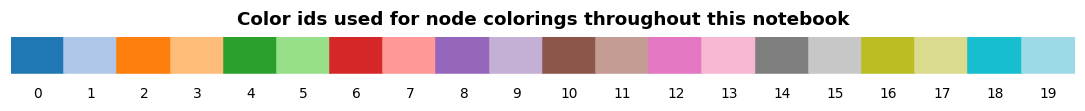

In [2]:
# A qualitative palette: color id -> RGBA. Ids cycle through 20 distinct hues.
_PALETTE = plt.get_cmap('tab20')

def color_of(cid):
    """Map an integer color id to a stable RGBA color."""
    return _PALETTE(int(cid) % 20)

def color_list(colors, nodes):
    """RGBA list for `nodes`, given a dict {node: color_id}."""
    return [color_of(colors[v]) for v in nodes]

# Accent colors used for highlighting
C_TARGET = '#E74C3C'   # the node under the microscope
C_EDGE   = '#95A5A6'   # ordinary edges
C_DARK   = '#2C3E50'   # outlines / text

fig, ax = plt.subplots(figsize=(10, 1.1))
for i in range(20):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color_of(i)))
    ax.text(i + 0.5, -0.35, str(i), ha='center', va='top', fontsize=9)
ax.set_xlim(0, 20); ax.set_ylim(-0.6, 1)
ax.set_title('Color ids used for node colorings throughout this notebook', pad=8)
ax.set_axis_off()
plt.tight_layout(); plt.show()

---

## 2. The Central Question

### 2.1 Two Graphs, One Prediction

Consider these two graphs on 6 nodes:

- $C_6$ — a single 6-cycle (one hexagon).
- $2 \times C_3$ — two disjoint triangles.

They are obviously **not isomorphic**: one is connected and triangle-free, the other has two components
and two triangles. Yet every node in both graphs has exactly **degree 2**. Let us see what a GNN makes
of them.

In [3]:
C6    = nx.cycle_graph(6)
TwoC3 = nx.disjoint_union(nx.cycle_graph(3), nx.cycle_graph(3))

def describe(name, G):
    return (f'{name:8s} | nodes {G.number_of_nodes():2d} | edges {G.number_of_edges():2d} '
            f'| components {nx.number_connected_components(G)} '
            f'| degrees {sorted(d for _, d in G.degree())} '
            f'| triangles {sum(nx.triangles(G).values()) // 3}')

print(describe('C6', C6))
print(describe('2 x C3', TwoC3))
print(f'\nIsomorphic? {nx.is_isomorphic(C6, TwoC3)}')

C6       | nodes  6 | edges  6 | components 1 | degrees [2, 2, 2, 2, 2, 2] | triangles 0
2 x C3   | nodes  6 | edges  6 | components 2 | degrees [2, 2, 2, 2, 2, 2] | triangles 2

Isomorphic? False


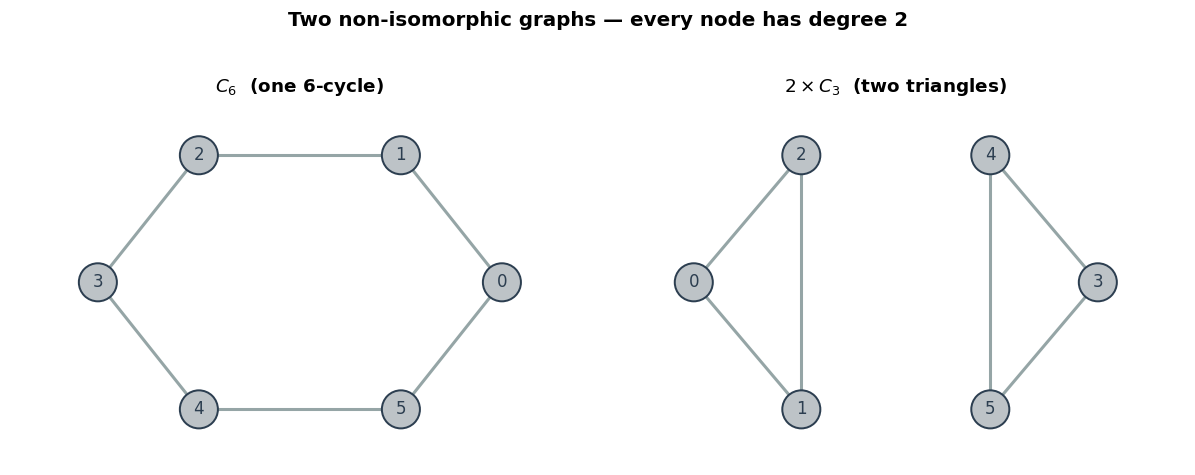

In [4]:
# Fixed layouts so these two graphs always look the same in later figures
POS_C6    = nx.circular_layout(C6)
POS_2C3   = {}
# Left triangle (0,1,2) rotated so node 0 points outward to the left, right
# triangle (3,4,5) so node 3 points outward to the right: the two components
# then read as clearly separate.
for i, n in enumerate([0, 1, 2]):
    ang = np.pi + 2 * np.pi * i / 3
    POS_2C3[n] = np.array([-1.0 + 0.55 * np.cos(ang), 0.55 * np.sin(ang)])
for i, n in enumerate([3, 4, 5]):
    ang = 2 * np.pi * i / 3
    POS_2C3[n] = np.array([1.0 + 0.55 * np.cos(ang), 0.55 * np.sin(ang)])

def draw_graph(G, pos, ax, colors=None, title=None, node_size=620,
               labels=True, highlight=None, font_size=11):
    """Draw a graph with optional WL colors and a highlighted node."""
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C_EDGE, width=2.0)
    nodes = list(G.nodes())
    if colors is None:
        fill = ['#BDC3C7'] * len(nodes)
    else:
        fill = color_list(colors, nodes)
    lw = [3.0 if (highlight is not None and v == highlight) else 1.3 for v in nodes]
    ec = [C_TARGET if (highlight is not None and v == highlight) else C_DARK for v in nodes]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax, node_color=fill,
                           edgecolors=ec, linewidths=lw, node_size=node_size)
    if labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size, font_color=C_DARK)
    if title:
        ax.set_title(title)
    ax.set_axis_off()
    ax.margins(0.15)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
draw_graph(C6, POS_C6, axes[0], title='$C_6$  (one 6-cycle)')
draw_graph(TwoC3, POS_2C3, axes[1], title='$2 \\times C_3$  (two triangles)')
plt.suptitle('Two non-isomorphic graphs — every node has degree 2',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 2.2 A Message-Passing GNN from Scratch

Before testing, we need a GNN. We implement a general message-passing network in the
**GIN** form (Xu et al., 2019), because it lets us switch the aggregator and see what changes:

$$h_v^{(\ell)} = \mathrm{MLP}^{(\ell)}\!\Big(\,(1+\varepsilon)\, h_v^{(\ell-1)} \;+\; \underset{u \in \mathcal{N}(v)}{\mathrm{AGG}}\; h_u^{(\ell-1)} \Big)$$

and a **graph-level** embedding by summing the node embeddings (readout):

$$h_G = \sum_{v \in V} h_v^{(L)}$$

We use **random, untrained** weights on purpose. Expressive power is a property of the *architecture* —
what functions it can possibly represent — not of any particular trained parameters. If an architecture
maps two graphs to the same embedding for *every* choice of weights, no amount of training can separate
them.

In [5]:
def adjacency(G, num_nodes=None):
    """Dense symmetric adjacency matrix (no self-loops) as a float tensor."""
    n = num_nodes or G.number_of_nodes()
    A = torch.zeros(n, n)
    for u, v in G.edges():
        A[u, v] = 1.0
        A[v, u] = 1.0
    return A


class MPNN(nn.Module):
    """
    A message-passing GNN in GIN form, with a switchable aggregator.

        h_v <- MLP( (1 + eps) * h_v  +  AGG_{u in N(v)} h_u )

    Parameters
    ----------
    dim_in, dim_hidden : feature dimensions
    num_layers         : number of message-passing rounds L
    agg                : 'sum' | 'mean' | 'max'  (the neighborhood aggregator)
    eps                : weight of the node's own previous representation
    seed               : seed for the random (untrained) weights
    """

    def __init__(self, dim_in, dim_hidden=32, num_layers=3, agg='sum', eps=0.1, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        assert agg in ('sum', 'mean', 'max')
        self.agg, self.num_layers, self.eps = agg, num_layers, eps
        dims = [dim_in] + [dim_hidden] * num_layers
        self.mlps = nn.ModuleList([
            nn.Sequential(nn.Linear(dims[i], dim_hidden), nn.ReLU(),
                          nn.Linear(dim_hidden, dim_hidden))
            for i in range(num_layers)
        ])

    def aggregate(self, h, A):
        """AGG over neighbors only (A has no self-loops)."""
        if self.agg == 'sum':
            return A @ h
        if self.agg == 'mean':
            return (A @ h) / A.sum(1, keepdim=True).clamp(min=1)
        # 'max': elementwise max over neighbors, 0 for isolated nodes
        out = torch.zeros_like(h)
        for i in range(h.shape[0]):
            nb = h[A[i] > 0]
            if nb.numel() > 0:
                out[i] = nb.max(dim=0).values
        return out

    def forward(self, X, A, return_all_layers=False):
        h = X
        history = [h]
        for layer in range(self.num_layers):
            h = self.mlps[layer]((1 + self.eps) * h + self.aggregate(h, A))
            history.append(h)
        return history if return_all_layers else h


@torch.no_grad()
def graph_embedding(G, dim_in=1, num_layers=3, agg='sum', eps=0.1, seed=0, X=None):
    """Sum-readout graph embedding from an untrained MPNN."""
    n = G.number_of_nodes()
    if X is None:
        X = torch.ones(n, dim_in)            # uniform features: no node identity given away
    model = MPNN(X.shape[1], 32, num_layers, agg, eps, seed)
    return model(X, adjacency(G, n)).sum(dim=0)

print('MPNN defined. Aggregators available: sum, mean, max.')

MPNN defined. Aggregators available: sum, mean, max.


### 2.3 The Experiment

We feed both graphs through the same network and compare their graph-level embeddings. We repeat over
several random weight initializations and all three aggregators — if *any* of them separates the
graphs, the architecture is expressive enough to tell them apart.

In [6]:
rows = []
for agg in ['sum', 'mean', 'max']:
    for seed in range(4):
        e1 = graph_embedding(C6,    agg=agg, seed=seed)
        e2 = graph_embedding(TwoC3, agg=agg, seed=seed)
        rows.append((agg, seed, (e1 - e2).abs().max().item()))

print(f"{'aggregator':>11s} {'seed':>5s} {'max |emb(C6) - emb(2xC3)|':>28s} {'separated?':>11s}")
print('-' * 60)
for agg, seed, diff in rows:
    print(f'{agg:>11s} {seed:>5d} {diff:>28.3e} {str(diff > TOL):>11s}')

worst = max(d for _, _, d in rows)
print(f'\nLargest difference over all 12 runs : {worst:.3e}')
print(f'Machine epsilon for float64          : {np.finfo(np.float64).eps:.3e}')
print(f'\nSeparated by any configuration?      {worst > TOL}')

 aggregator  seed    max |emb(C6) - emb(2xC3)|  separated?
------------------------------------------------------------
        sum     0                    4.441e-16       False
        sum     1                    1.776e-15       False
        sum     2                    1.776e-15       False
        sum     3                    8.882e-16       False
       mean     0                    8.882e-16       False
       mean     1                    3.331e-16       False
       mean     2                    4.441e-16       False
       mean     3                    2.220e-16       False
        max     0                    8.882e-16       False
        max     1                    2.220e-16       False
        max     2                    4.441e-16       False
        max     3                    2.220e-16       False

Largest difference over all 12 runs : 1.776e-15
Machine epsilon for float64          : 2.220e-16

Separated by any configuration?      False


> **Result.** The difference is zero to within floating-point round-off ($\sim 10^{-15}$, a few machine
> epsilons) for every aggregator and every initialization — the two embeddings are the *same vector*,
> and the residue is only the cost of adding the same numbers in a different order. This is not an
> optimization failure or an unlucky initialization: **no** message-passing GNN of this form can
> distinguish a hexagon from two triangles.
>
> Any downstream task that depends on the difference (e.g. "does this molecule contain a ring of size
> 6?") is therefore unlearnable by such a model. To understand *why*, we need to look at what a node
> actually receives during message passing.

---

## 3. The Computational Graph

### 3.1 What a Node Actually Sees

Fix a node $v$ and run $L$ rounds of message passing. To compute $h_v^{(L)}$ we need:

- $h_v^{(L-1)}$ and $h_u^{(L-1)}$ for all neighbors $u \in \mathcal{N}(v)$,
- which in turn need the layer-$(L-2)$ representations of *their* neighbors,
- and so on, $L$ levels deep.

Unrolling this dependency gives the **computational graph** of $v$ — also called its **unfolding tree**
or **rooted subtree**. It is built by:

1. Put $v$ at the root (level 0).
2. For each node at level $d$, attach a **copy** of *every* one of its neighbors at level $d+1$.
3. Stop at level $L$.

Two details matter enormously:

- **It is a tree, not a subgraph.** A node reached by two different paths appears as two separate
  copies. The tree records *walks* from the root, and it never "notices" that two copies are really the
  same node.
- **The sender is not excluded.** Standard message passing has no "don't send back where you came from"
  rule, so $v$ itself reappears at level 2, and so on.

In [7]:
def unfolding_tree(G, root, depth):
    """
    Build the computational graph (unfolding tree) of `root` for a depth-layer MPNN.

    Tree nodes are *walks* in G starting at `root`, so the same original node can
    appear many times. Node attributes:
        'orig'  : which node of G this copy corresponds to
        'level' : depth in the tree (0 = root)
    Edges point child -> parent, i.e. in the direction messages travel.
    """
    T = nx.DiGraph()
    T.add_node((root,), orig=root, level=0)
    frontier = [(root,)]
    for d in range(depth):
        next_frontier = []
        for walk in frontier:
            for u in sorted(G.neighbors(walk[-1])):
                child = walk + (u,)
                T.add_node(child, orig=u, level=d + 1)
                T.add_edge(child, walk)          # child sends its message to parent
                next_frontier.append(child)
        frontier = next_frontier
    return T


def tree_layout(T, root, x_gap=1.0, y_gap=1.0):
    """Layered layout: root on top, each parent centered above its children."""
    pos, cursor = {}, [0.0]

    def place(n):
        children = sorted(T.predecessors(n))     # edges point child -> parent
        if not children:
            x = cursor[0]
            cursor[0] += x_gap
        else:
            x = float(np.mean([place(c) for c in children]))
        pos[n] = (x, -T.nodes[n]['level'] * y_gap)
        return x

    place(root)
    return pos


def draw_tree(T, root, ax, colors=None, title=None, node_size=460, font_size=9):
    """Draw an unfolding tree; `colors` is a dict {original node: color_id}."""
    pos = tree_layout(T, root)
    nodes = list(T.nodes())
    if colors is None:
        fill = [color_of(T.nodes[n]['orig']) for n in nodes]
    else:
        fill = [color_of(colors[T.nodes[n]['orig']]) for n in nodes]
    nx.draw_networkx_edges(T, pos, ax=ax, arrows=False, edge_color=C_EDGE, width=1.4)
    nx.draw_networkx_nodes(T, pos, nodelist=nodes, ax=ax, node_color=fill,
                           edgecolors=C_DARK, linewidths=1.1, node_size=node_size)
    nx.draw_networkx_labels(T, pos, {n: str(T.nodes[n]['orig']) for n in nodes},
                            ax=ax, font_size=font_size, font_color=C_DARK)
    if title:
        ax.set_title(title)
    ax.set_axis_off()
    ax.margins(0.08)


T_demo = unfolding_tree(C6, root=0, depth=2)
print(f'Unfolding tree of node 0 in C6, depth 2: {T_demo.number_of_nodes()} tree nodes')
print(f'  level sizes: {Counter(d["level"] for _, d in T_demo.nodes(data=True))}')
print(f'  note node 0 reappears at level 2 (walks 0->1->0 and 0->5->0):')
print(f'  {[w for w, d in T_demo.nodes(data=True) if d["level"] == 2 and d["orig"] == 0]}')

Unfolding tree of node 0 in C6, depth 2: 7 tree nodes
  level sizes: Counter({2: 4, 1: 2, 0: 1})
  note node 0 reappears at level 2 (walks 0->1->0 and 0->5->0):
  [(0, 1, 0), (0, 5, 0)]


### 3.2 From Graph to Computational Graph

Let's put a graph and the unfolding tree of one of its nodes side by side. We use a small
asymmetric graph so the tree structure is easy to read.

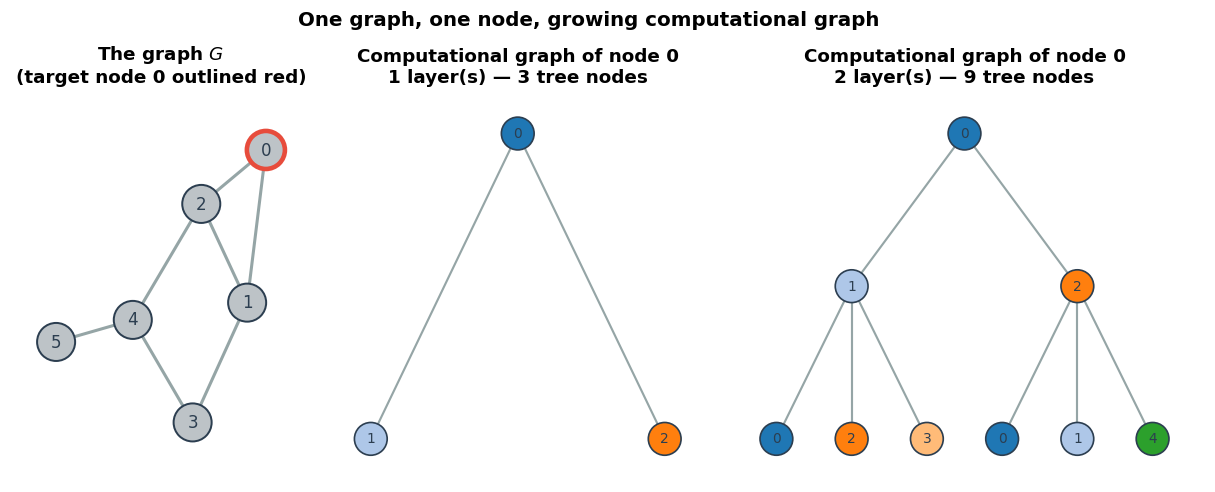

In [8]:
G_demo = nx.Graph([(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4), (4, 5)])
POS_DEMO = nx.spring_layout(G_demo, seed=3)

fig = plt.figure(figsize=(14, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.25, 1.6], wspace=0.05)

ax = fig.add_subplot(gs[0])
draw_graph(G_demo, POS_DEMO, ax, title='The graph $G$\n(target node 0 outlined red)',
           highlight=0)

for k, depth in enumerate([1, 2]):
    ax = fig.add_subplot(gs[k + 1])
    T = unfolding_tree(G_demo, 0, depth)
    draw_tree(T, (0,), ax, title=f'Computational graph of node 0\n{depth} layer(s) — '
                                 f'{T.number_of_nodes()} tree nodes')

plt.suptitle('One graph, one node, growing computational graph',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

**Read the tree bottom-up.** Messages flow upward: the leaves pass their features to their parents,
those combine and pass upward again, and after $L$ steps the root holds $h_0^{(L)}$.

Notice how quickly copies multiply. Node 0 has degree 2, and already at depth 2 the tree contains
repeated copies of nodes 1, 2 and 0 itself. The tree size grows roughly like $d^L$ for average degree
$d$ — which is also why deep GNNs suffer from **over-squashing**: exponentially much information is
being crushed into one fixed-size vector.

In [9]:
# How the receptive field and the tree size grow with depth
print(f"{'depth L':>8s} {'tree nodes':>11s} {'distinct original nodes':>25s}")
print('-' * 47)
for depth in range(5):
    T = unfolding_tree(G_demo, 0, depth)
    distinct = len({d['orig'] for _, d in T.nodes(data=True)})
    print(f'{depth:>8d} {T.number_of_nodes():>11d} {distinct:>25d}')
print(f'\n(The graph has only {G_demo.number_of_nodes()} nodes, '
      f'but the depth-4 tree has far more — copies, not nodes.)')

 depth L  tree nodes   distinct original nodes
-----------------------------------------------
       0           1                         1
       1           3                         3
       2           9                         5
       3          24                         6
       4          63                         6

(The graph has only 6 nodes, but the depth-4 tree has far more — copies, not nodes.)


### 3.3 The Key Lemma

Everything about expressive power follows from one observation:

> **Lemma.** A message-passing GNN computes $h_v^{(L)}$ as a function of the depth-$L$ unfolding tree
> of $v$ (with input features attached), and *nothing else*.
>
> **Consequence.** If two nodes $u, v$ — possibly in different graphs — have **identical** unfolding
> trees, then $h_u^{(L)} = h_v^{(L)}$ for **every** message-passing GNN, at every setting of its
> weights.

The GNN never sees the graph. It sees a rooted tree. Any two graphs that produce the same *collection*
of rooted trees are indistinguishable.

Let's apply this to $C_6$ and $2 \times C_3$.

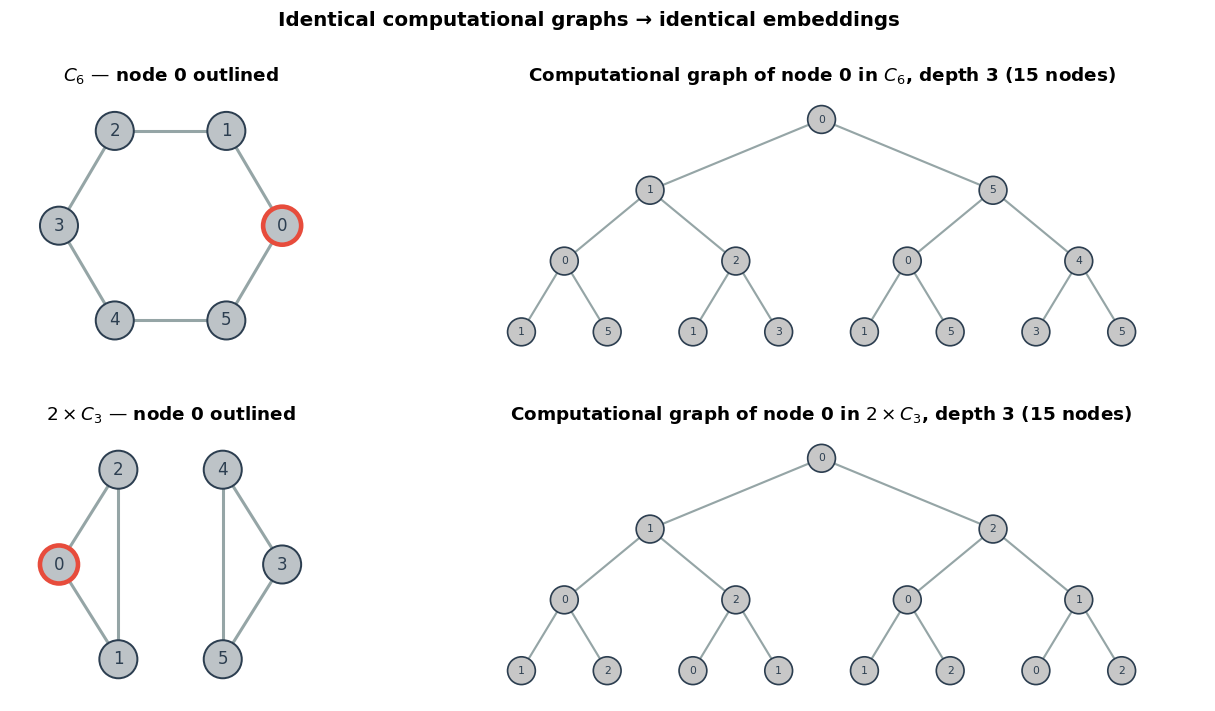

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7.2),
                         gridspec_kw={'width_ratios': [1, 2.4], 'hspace': 0.25})

for row, (name, G, pos) in enumerate([('$C_6$', C6, POS_C6),
                                      ('$2 \\times C_3$', TwoC3, POS_2C3)]):
    draw_graph(G, pos, axes[row][0], title=f'{name} — node 0 outlined', highlight=0)
    T = unfolding_tree(G, 0, 3)
    # Color every tree node the same neutral gray: the input features are uniform,
    # so only the *shape* of the tree can possibly matter.
    uniform = {v: 15 for v in G.nodes()}
    draw_tree(T, (0,), axes[row][1], colors=uniform,
              title=f'Computational graph of node 0 in {name}, depth 3 '
                    f'({T.number_of_nodes()} nodes)', node_size=330, font_size=7)

plt.suptitle('Identical computational graphs → identical embeddings',
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout(); plt.show()

The two trees are **the same perfect binary tree**. Every node in both graphs has degree 2, so every
unfolding tree is a complete binary tree of depth $L$ — the hexagon's cycle of length 6 and the
triangles' cycles of length 3 are both invisible, because a tree has no cycles to record.

Let's verify the trees are isomorphic as *labeled-by-shape* trees rather than trusting the picture.

In [11]:
def tree_shape(T, node):
    """
    Canonical form of the subtree rooted at `node`, ignoring node identities.
    Two unfolding trees have equal canonical forms iff they are isomorphic as
    rooted trees (with uniform input features).
    """
    children = sorted(T.predecessors(node))
    return tuple(sorted(tree_shape(T, c) for c in children))


for depth in [1, 2, 3, 4]:
    s1 = tree_shape(unfolding_tree(C6, 0, depth), (0,))
    s2 = tree_shape(unfolding_tree(TwoC3, 0, depth), (0,))
    print(f'depth {depth}: unfolding trees identical? {s1 == s2}')

print('\nAnd for every pair of nodes, one from each graph:')
same = all(tree_shape(unfolding_tree(C6, u, 3), (u,)) ==
           tree_shape(unfolding_tree(TwoC3, v, 3), (v,))
           for u in C6.nodes() for v in TwoC3.nodes())
print(f'  all 6 x 6 node pairs have identical depth-3 trees: {same}')

depth 1: unfolding trees identical? True
depth 2: unfolding trees identical? True
depth 3: unfolding trees identical? True
depth 4: unfolding trees identical? True

And for every pair of nodes, one from each graph:
  all 6 x 6 node pairs have identical depth-3 trees: True


> **This fully explains §2.3.** Every node of $C_6$ and every node of $2 \times C_3$ has the same
> computational graph, so all 12 nodes receive the *same* embedding, so the two sum-readouts are equal.
> The zero difference we measured was inevitable.
>
> Now we need a way to *systematically* detect when two nodes have the same computational graph —
> without building exponentially large trees. That tool is node coloring.

---

## 4. Node Coloring: The 1-WL Algorithm

### 4.1 The Refinement Rule

The **1-dimensional Weisfeiler–Leman algorithm** (1-WL), also called **color refinement**, computes
exactly the information in the unfolding trees, but iteratively and in polynomial time.

Every node starts with the same color. Then repeat:

$$c^{(\ell)}(v) \;=\; \mathrm{HASH}\Big(\, c^{(\ell-1)}(v), \;\; \{\!\!\{\, c^{(\ell-1)}(u) \;:\; u \in \mathcal{N}(v) \,\}\!\!\} \,\Big)$$

where $\{\!\!\{\cdot\}\!\!\}$ is a **multiset** (a set that remembers multiplicities but not order) and
$\mathrm{HASH}$ is **injective** — distinct inputs always get distinct colors.

Three properties make this the right tool:

1. **It mirrors message passing exactly.** Compare the rule above with
   $h_v^{(\ell)} = \mathrm{MLP}\big((1+\varepsilon)h_v^{(\ell-1)} + \sum_{u} h_u^{(\ell-1)}\big)$:
   both combine *my previous state* with *the multiset of my neighbors' previous states*.
2. **Colors encode trees.** After $\ell$ rounds, $c^{(\ell)}(v) = c^{(\ell)}(u)$ **iff** $u$ and $v$
   have identical depth-$\ell$ unfolding trees. The coloring is a compressed tree fingerprint.
3. **It is cheap.** $O(L \cdot |E|)$ time, versus exponentially large trees.

The *multiset* is the crucial design choice: a node learns *what* its neighbors are and *how many* of
each — but not which is which, and in what order. That is precisely the permutation invariance we want,
and precisely the source of the blindness we are studying.

In [12]:
def wl_refine(graphs, num_iterations=3, init_fn=None):
    """
    1-WL color refinement, run *jointly* over a list of graphs.

    Running jointly with one shared HASH table is what makes colors comparable
    across graphs: the same (own color, neighbor multiset) signature gets the
    same color id no matter which graph it came from.

    Parameters
    ----------
    graphs        : list of nx.Graph
    num_iterations: number of refinement rounds
    init_fn       : (G, v) -> hashable initial label. Default: one color for all.

    Returns
    -------
    history : list of length num_iterations+1; history[l][i] is the dict
              {node: color_id} for graphs[i] after l rounds.
    """
    table, next_id = {}, 0

    def hash_to_color(signature):
        """Injective HASH: a fresh color id for every unseen signature."""
        nonlocal next_id
        if signature not in table:
            table[signature] = next_id
            next_id += 1
        return table[signature]

    if init_fn is None:
        init_fn = lambda G, v: ('uniform',)

    colors = [{v: hash_to_color(init_fn(G, v)) for v in G.nodes()} for G in graphs]
    history = [[dict(c) for c in colors]]

    for _ in range(num_iterations):
        new_colors = []
        for G, c in zip(graphs, colors):
            nc = {}
            for v in G.nodes():
                neighbor_multiset = tuple(sorted(c[u] for u in G.neighbors(v)))
                nc[v] = hash_to_color((c[v], neighbor_multiset))
            new_colors.append(nc)
        colors = new_colors
        history.append([dict(c) for c in colors])

    return history


def color_histogram(colors):
    """Multiset of colors present — the graph-level WL fingerprint."""
    return Counter(colors.values())


def wl_distinguishes(G1, G2, num_iterations=10, init_fn=None):
    """True iff 1-WL separates the two graphs within num_iterations rounds."""
    history = wl_refine([G1, G2], num_iterations, init_fn)
    return any(color_histogram(s[0]) != color_histogram(s[1]) for s in history)


print('1-WL implemented.')

1-WL implemented.


### 4.2 Step by Step on a Path

The clearest first example is a path $P_7$. All nodes start identical; refinement then peels the path
like an onion, because the two endpoints are the only degree-1 nodes and that distinction spreads
inward one hop per round.

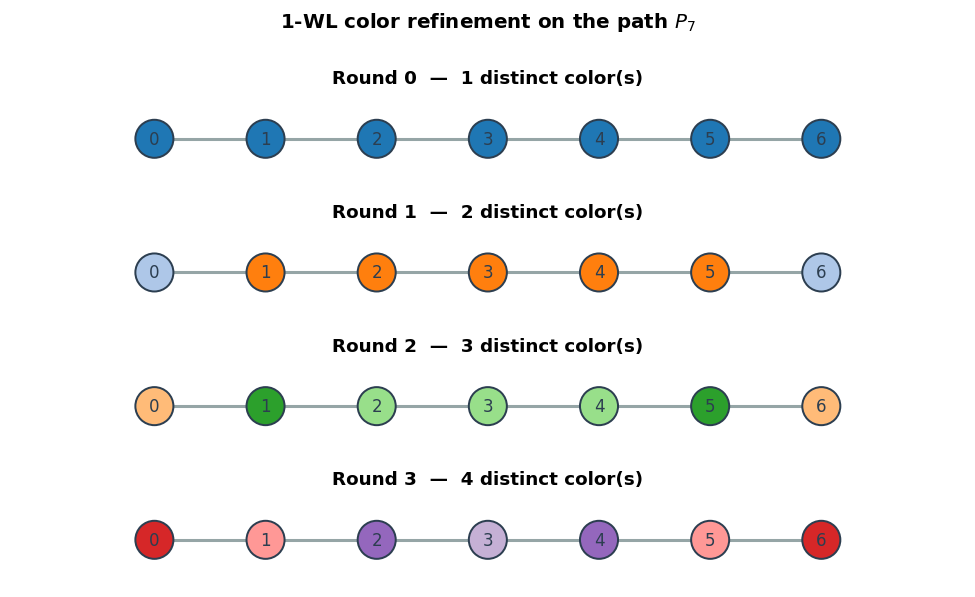

In [13]:
P7 = nx.path_graph(7)
POS_P7 = {i: (i, 0) for i in P7.nodes()}

history = wl_refine([P7], num_iterations=3)

fig, axes = plt.subplots(4, 1, figsize=(9, 5.4))
for l, ax in enumerate(axes):
    colors = history[l][0]
    draw_graph(P7, POS_P7, ax, colors=colors, node_size=620,
               title=f'Round {l}  —  {len(set(colors.values()))} distinct color(s)')
plt.suptitle('1-WL color refinement on the path $P_7$',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

In [14]:
# The same thing as numbers, so the refinement rule is fully transparent
print('Node colors after each round (path P7):\n')
print(f"{'round':>6s} | " + ' '.join(f'{v:>4d}' for v in P7.nodes()) + '  | #classes')
print('-' * 56)
for l, step in enumerate(history):
    c = step[0]
    print(f'{l:>6d} | ' + ' '.join(f'{c[v]:>4d}' for v in P7.nodes())
          + f'  | {len(set(c.values())):>4d}')

print('\nWhy node 1 and node 2 split at round 2:')
c1 = history[1][0]
for v in [1, 2]:
    ms = sorted(c1[u] for u in P7.neighbors(v))
    print(f'  node {v}: own color {c1[v]}, neighbor multiset {{{{ {", ".join(map(str, ms))} }}}}'
          f'  ->  new color {history[2][0][v]}')

Node colors after each round (path P7):

 round |    0    1    2    3    4    5    6  | #classes
--------------------------------------------------------
     0 |    0    0    0    0    0    0    0  |    1
     1 |    1    2    2    2    2    2    1  |    2
     2 |    3    4    5    5    5    4    3  |    3
     3 |    6    7    8    9    8    7    6  |    4

Why node 1 and node 2 split at round 2:
  node 1: own color 2, neighbor multiset {{ 1, 2 }}  ->  new color 4
  node 2: own color 2, neighbor multiset {{ 2, 2 }}  ->  new color 5


### 4.3 Convergence to a Stable Partition

Refinement can only ever **split** color classes, never merge them. Since there are at most $n$
classes, the partition must **stabilize** after at most $n-1$ rounds — and in practice far sooner.
Once stable, further rounds change nothing, which is why very deep GNNs gain no *extra* discriminative
power from depth alone.

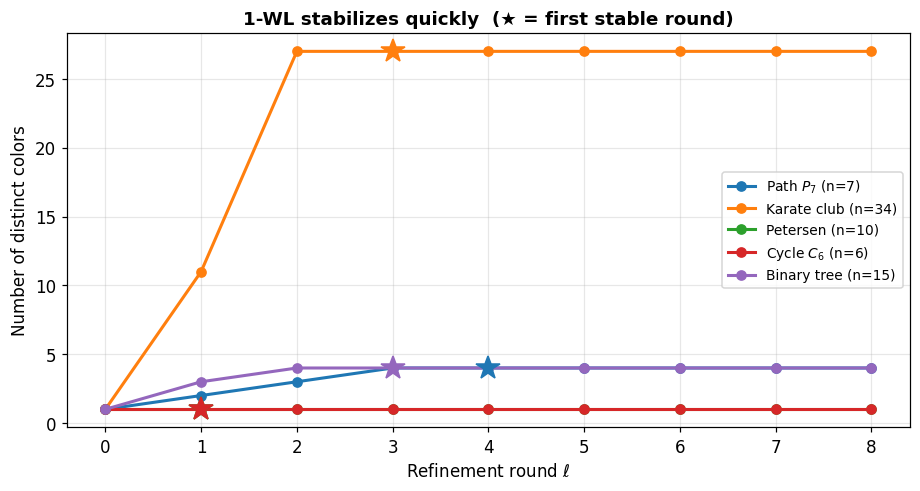

In [15]:
def refinement_curve(G, max_iterations=10):
    """Number of distinct colors after each round, plus the round it stabilizes."""
    history = wl_refine([G], max_iterations)
    counts = [len(set(step[0].values())) for step in history]
    stable = next((l for l in range(1, len(counts)) if counts[l] == counts[l - 1]),
                  len(counts) - 1)
    return counts, stable


examples = [('Path $P_7$', P7),
            ('Karate club', nx.karate_club_graph()),
            ('Petersen', nx.petersen_graph()),
            ('Cycle $C_6$', C6),
            ('Binary tree', nx.balanced_tree(2, 3))]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for name, G in examples:
    G = nx.convert_node_labels_to_integers(G)
    counts, stable = refinement_curve(G, 8)
    ax.plot(range(len(counts)), counts, marker='o', linewidth=2, label=f'{name} (n={G.number_of_nodes()})')
    ax.plot(stable, counts[stable], marker='*', markersize=16,
            color=ax.lines[-1].get_color(), zorder=5)
ax.set_xlabel('Refinement round $\\ell$')
ax.set_ylabel('Number of distinct colors')
ax.set_title('1-WL stabilizes quickly  (★ = first stable round)')
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 4.4 Coloring a Real Graph

On the Karate club network the stable coloring is a structural summary: nodes in the same class are
**structurally indistinguishable** to 1-WL, and therefore to any message-passing GNN.

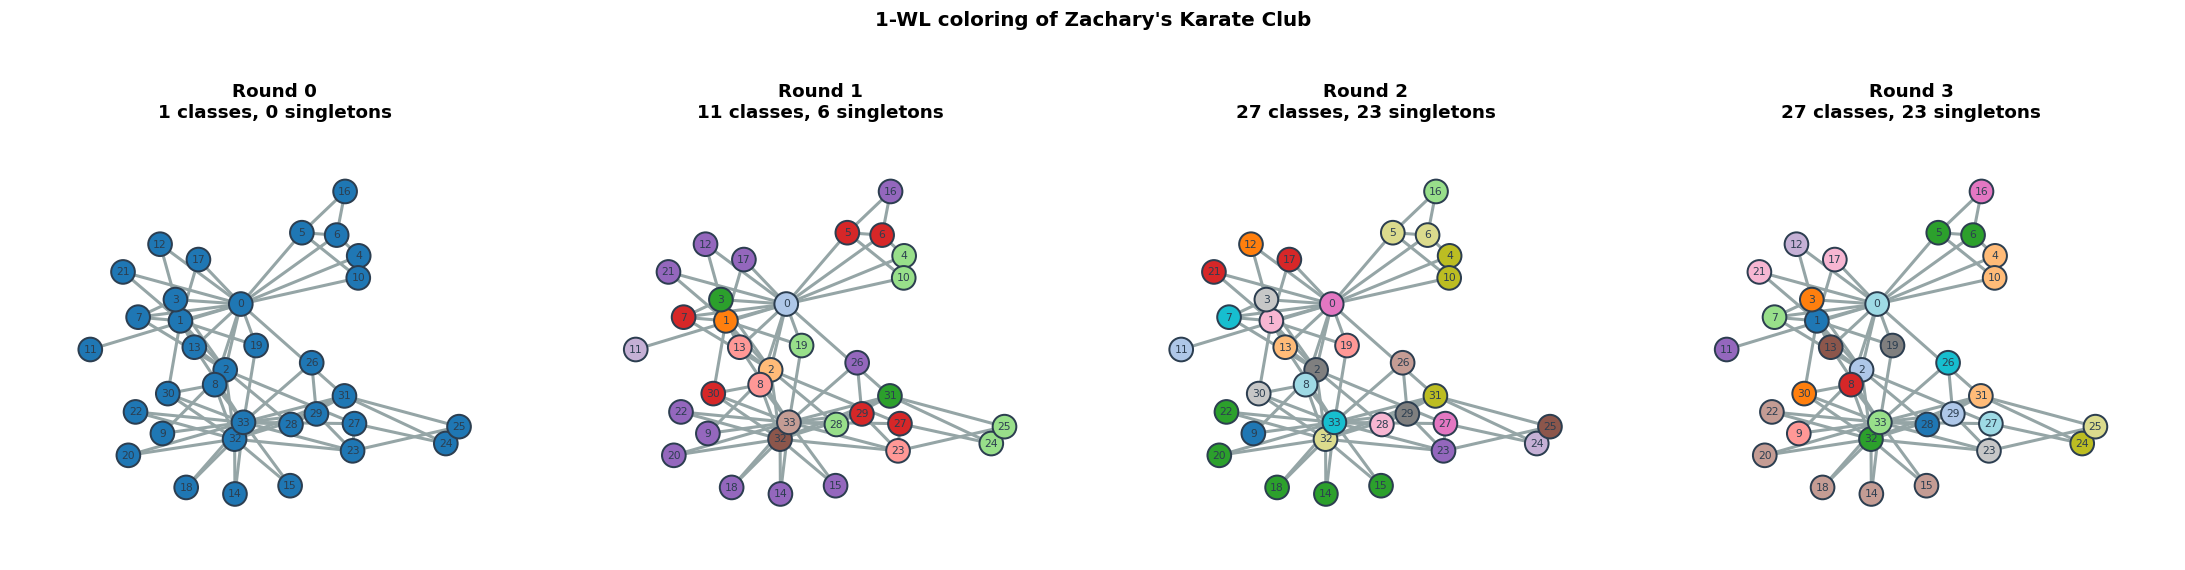

After 3 rounds: 27 classes for 34 nodes.
Classes with more than one node (structurally equivalent to 1-WL):
  color  51: nodes [14, 15, 18, 20, 22]  (degrees [2, 2, 2, 2, 2])
  color  43: nodes [4, 10]  (degrees [3, 3])
  color  44: nodes [5, 6]  (degrees [4, 4])
  color  53: nodes [17, 21]  (degrees [2, 2])


In [16]:
KC = nx.karate_club_graph()
POS_KC = nx.spring_layout(KC, seed=42, k=0.5)
kc_history = wl_refine([KC], num_iterations=3)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for l, ax in enumerate(axes):
    colors = kc_history[l][0]
    sizes = Counter(colors.values())
    singletons = sum(1 for s in sizes.values() if s == 1)
    draw_graph(KC, POS_KC, ax, colors=colors, node_size=240, font_size=7,
               title=f'Round {l}\n{len(sizes)} classes, {singletons} singletons')
plt.suptitle('1-WL coloring of Zachary\'s Karate Club', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

final = kc_history[-1][0]
groups = defaultdict(list)
for v, c in final.items():
    groups[c].append(v)
non_trivial = {c: vs for c, vs in groups.items() if len(vs) > 1}
print(f'After 3 rounds: {len(groups)} classes for {KC.number_of_nodes()} nodes.')
print(f'Classes with more than one node (structurally equivalent to 1-WL):')
for c, vs in sorted(non_trivial.items(), key=lambda kv: -len(kv[1])):
    print(f'  color {c:>3d}: nodes {vs}  (degrees {[KC.degree(v) for v in vs]})')

### 4.5 The WL Graph Isomorphism Test

To compare two *graphs*, refine both with a shared hash table and compare their **color histograms**
at each round. If the histograms ever differ, the graphs are **provably non-isomorphic**.

The test is **one-sided**:

- histograms differ $\Rightarrow$ **not isomorphic** (a certificate, always correct);
- histograms agree $\Rightarrow$ **inconclusive**. The graphs may be isomorphic, or 1-WL may simply be
  too weak.

Our two graphs land in that second case.

In [17]:
def wl_report(G1, G2, name1, name2, num_iterations=4):
    """Print the round-by-round color histograms of two graphs."""
    history = wl_refine([G1, G2], num_iterations)
    print(f'{name1}  vs  {name2}')
    print('-' * 64)
    verdict = False
    for l, step in enumerate(history):
        h1, h2 = color_histogram(step[0]), color_histogram(step[1])
        same = h1 == h2
        verdict = verdict or not same
        fmt = lambda h: '{' + ', '.join(f'{c}:{n}' for c, n in sorted(h.items())) + '}'
        print(f'  round {l}: {fmt(h1):<28s} {"==" if same else "!="} {fmt(h2)}')
    print(f'\n  1-WL verdict: {"NON-ISOMORPHIC (certificate found)" if verdict else "INCONCLUSIVE"}')
    print(f'  ground truth: {"isomorphic" if nx.is_isomorphic(G1, G2) else "NON-isomorphic"}')
    return verdict


wl_report(C6, TwoC3, 'C6', '2 x C3')

C6  vs  2 x C3
----------------------------------------------------------------
  round 0: {0:6}                        == {0:6}
  round 1: {1:6}                        == {1:6}
  round 2: {2:6}                        == {2:6}
  round 3: {3:6}                        == {3:6}
  round 4: {4:6}                        == {4:6}

  1-WL verdict: INCONCLUSIVE
  ground truth: NON-isomorphic


False

In [18]:
# Sanity check against NetworkX's own WL hash — an independent implementation
h1 = nx.weisfeiler_lehman_graph_hash(C6, iterations=4)
h2 = nx.weisfeiler_lehman_graph_hash(TwoC3, iterations=4)
print(f'networkx WL hash, C6    : {h1}')
print(f'networkx WL hash, 2 x C3: {h2}')
print(f'\nHashes equal (i.e. networkx 1-WL also fails): {h1 == h2}')

# And a positive control: a pair 1-WL *does* separate
P = nx.path_graph(5)
S = nx.star_graph(4)
print(f'\nPositive control — P5 vs star S4: 1-WL distinguishes = {wl_distinguishes(P, S)}')

networkx WL hash, C6    : 0e5a55feaa9cb646f40c425a6d635394
networkx WL hash, 2 x C3: 0e5a55feaa9cb646f40c425a6d635394

Hashes equal (i.e. networkx 1-WL also fails): True

Positive control — P5 vs star S4: 1-WL distinguishes = True


---

## 5. Message-Passing GNNs Are Exactly as Powerful as 1-WL

### 5.1 The Theorem

Independently, Xu et al. (*How Powerful are Graph Neural Networks?*, ICLR 2019) and Morris et al.
(*Weisfeiler and Leman Go Neural*, AAAI 2019) proved the two halves of the following statement.

> **Upper bound.** For any message-passing GNN and any two graphs $G, H$: if 1-WL assigns them the same
> color histogram, the GNN assigns them the same embedding. So **no MPNN exceeds 1-WL**.
>
> **Matching lower bound.** There *exists* a message-passing GNN that is as discriminative as 1-WL —
> provided every aggregation and update step is **injective on multisets**.

The upper bound holds because a GNN layer is a *particular* choice of the $\mathrm{HASH}$ in 1-WL.
Concretely, $\mathrm{MLP}\big((1+\varepsilon)h_v + \sum_u h_u\big)$ is *some* function of
$(c(v), \{\!\!\{c(u)\}\!\!\})$ — and possibly a lossy one, since an MLP need not be injective. 1-WL uses
a perfect hash, so it is the best case. A GNN can match it, never beat it.

### 5.2 Verifying the Bound Numerically

We can test the theorem directly. Run an untrained sum-aggregating MPNN for $L$ layers, group nodes
whose embeddings coincide, and compare that partition with the 1-WL partition after $L$ rounds. They
should match.

One practical detail: GNN embeddings are floats, so we group them with a scale-aware tolerance rather
than exact equality.

In [19]:
def partition_by_embedding(H, tol=1e-3):
    """
    Group rows of H that agree up to a scale-aware tolerance.
    Returns an integer label per row, i.e. the partition the GNN induces.
    """
    H = H.detach().numpy()
    n = len(H)
    scale = max(np.abs(H).max(), 1e-12)
    labels = -np.ones(n, dtype=int)
    next_label = 0
    for i in range(n):
        if labels[i] >= 0:
            continue
        labels[i] = next_label
        for j in range(i + 1, n):
            if labels[j] < 0 and np.abs(H[i] - H[j]).max() <= tol * scale:
                labels[j] = next_label
        next_label += 1
    return labels


def same_partition(labels, colors, nodes):
    """True iff the GNN labels and the WL colors induce the same partition."""
    gnn = defaultdict(set)
    wl = defaultdict(set)
    for i, v in enumerate(nodes):
        gnn[labels[i]].add(v)
        wl[colors[v]].add(v)
    return {frozenset(s) for s in gnn.values()} == {frozenset(s) for s in wl.values()}


@torch.no_grad()
def compare_gnn_to_wl(G, num_layers, seed=1):
    G = nx.convert_node_labels_to_integers(G)
    nodes = list(G.nodes())
    n = len(nodes)
    H = MPNN(1, 32, num_layers, 'sum', eps=0.1, seed=seed)(torch.ones(n, 1), adjacency(G))
    labels = partition_by_embedding(H)
    colors = wl_refine([G], num_layers)[num_layers][0]
    return len(set(labels)), len(set(colors.values())), same_partition(labels, colors, nodes)


test_graphs = [('Karate club', nx.karate_club_graph()),
               ('Petersen', nx.petersen_graph()),
               ('Path $P_7$', nx.path_graph(7)),
               ('Binary tree', nx.balanced_tree(2, 3)),
               ('Cycle $C_6$', C6),
               ('3-cube', nx.hypercube_graph(3)),
               ('$K_4$', nx.complete_graph(4)),
               ('Two triangles', TwoC3)]

print(f"{'graph':>14s} {'L':>3s} {'GNN classes':>12s} {'1-WL classes':>13s} {'same partition':>15s}")
print('-' * 62)
all_match = True
for name, G in test_graphs:
    for L in [1, 2, 3]:
        g, w, ok = compare_gnn_to_wl(G, L)
        all_match &= ok
        print(f'{name:>14s} {L:>3d} {g:>12d} {w:>13d} {str(ok):>15s}')
print(f'\nGNN partition == 1-WL partition in every case: {all_match}')

         graph   L  GNN classes  1-WL classes  same partition
--------------------------------------------------------------
   Karate club   1           11            11            True
   Karate club   2           27            27            True
   Karate club   3           27            27            True
      Petersen   1            1             1            True
      Petersen   2            1             1            True
      Petersen   3            1             1            True
    Path $P_7$   1            2             2            True
    Path $P_7$   2            3             3            True
    Path $P_7$   3            4             4            True
   Binary tree   1            3             3            True
   Binary tree   2            4             4            True
   Binary tree   3            4             4            True
   Cycle $C_6$   1            1             1            True
   Cycle $C_6$   2            1             1            True
   Cycl

> The partitions coincide everywhere. The GNN is not merely *bounded* by 1-WL — with a sum aggregator
> it actually *achieves* the bound on these graphs. Next we see why the choice of aggregator is what
> makes or breaks this.

### 5.3 Injectivity: Why the Aggregator Decides Everything

The lower bound required the aggregator to be **injective on multisets**. Let's see which aggregators
are. The question is concrete: given two different neighbor multisets, does the aggregator produce
different outputs?

In [20]:
# Two one-hot "colors": red = (1,0), blue = (0,1)
red, blue = torch.tensor([1., 0.]), torch.tensor([0., 1.])

cases = [
    ('mean & max fail', [red, blue], [red, red, blue, blue]),
    ('max fails',       [red, blue], [red, blue, blue]),
    ('all succeed',     [red],       [blue]),
]

print(f"{'case':>16s}  {'multiset A':>16s} {'multiset B':>16s} | "
      f"{'sum':>7s} {'mean':>7s} {'max':>7s}")
print('-' * 82)
for label, A, B in cases:
    SA, SB = torch.stack(A), torch.stack(B)
    desc = lambda M: '{' + ','.join('r' if x[0] > 0 else 'b' for x in M) + '}'
    res = {}
    for agg, fn in [('sum', lambda M: M.sum(0)),
                    ('mean', lambda M: M.mean(0)),
                    ('max', lambda M: M.max(0).values)]:
        res[agg] = 'SPLIT' if not torch.allclose(fn(SA), fn(SB)) else 'same'
    print(f'{label:>16s}  {desc(SA):>16s} {desc(SB):>16s} | '
          f'{res["sum"]:>7s} {res["mean"]:>7s} {res["max"]:>7s}')

print('\n"same" = the aggregator collapses two different multisets => information lost.')

            case        multiset A       multiset B |     sum    mean     max
----------------------------------------------------------------------------------
 mean & max fail             {r,b}        {r,r,b,b} |   SPLIT    same    same
       max fails             {r,b}          {r,b,b} |   SPLIT   SPLIT    same
     all succeed               {r}              {b} |   SPLIT   SPLIT   SPLIT

"same" = the aggregator collapses two different multisets => information lost.


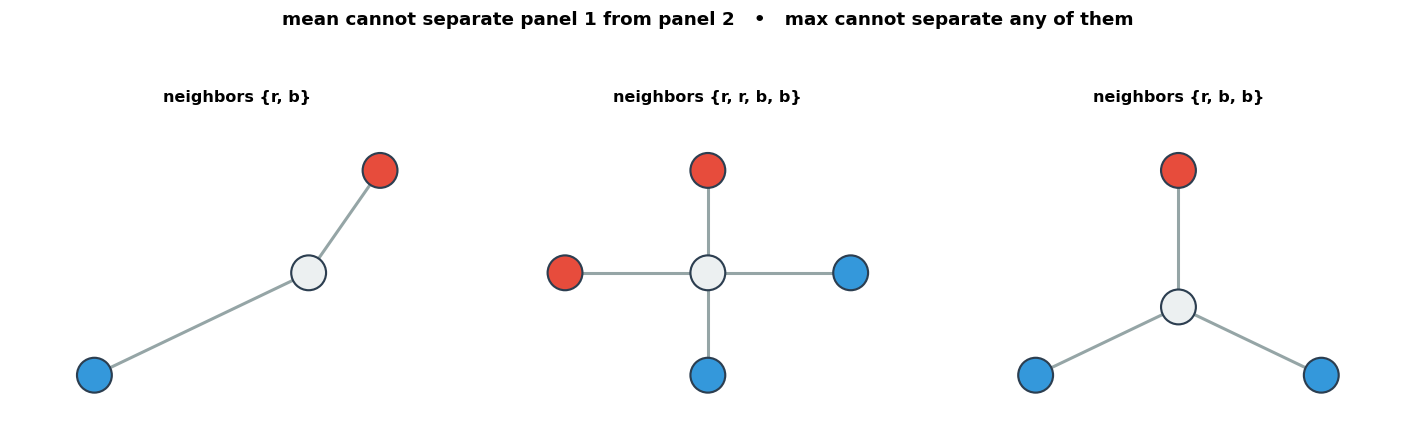

In [21]:
# The same three cases, drawn as neighborhoods (cf. Xu et al. 2019, Fig. 3)
def draw_neighborhood(ax, neighbor_colors, title):
    """Draw a center node with the given colored neighbors."""
    k = len(neighbor_colors)
    G = nx.star_graph(k)
    pos = {0: (0, 0)}
    for i in range(k):
        angle = np.pi / 2 + 2 * np.pi * i / k
        pos[i + 1] = (np.cos(angle), np.sin(angle))
    fill = ['#ECF0F1'] + ['#E74C3C' if c == 'r' else '#3498DB' for c in neighbor_colors]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C_EDGE, width=2.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=fill, edgecolors=C_DARK,
                           linewidths=1.4, node_size=520)
    ax.set_title(title, fontsize=10.5)
    ax.set_axis_off()
    ax.margins(0.22)


panels = [('{r, b}', 'rb'), ('{r, r, b, b}', 'rrbb'), ('{r, b, b}', 'rbb')]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (title, cs) in zip(axes, panels):
    draw_neighborhood(ax, cs, f'neighbors {title}')
plt.suptitle('mean cannot separate panel 1 from panel 2   •   max cannot separate any of them',
             fontsize=12, fontweight='bold', y=1.06)
plt.tight_layout(); plt.show()

**The verdict on aggregators:**

| Aggregator | Injective on multisets? | What it loses | Expressive power |
|---|---|---|---|
| **sum** | ✅ yes (for one-hot / countably many features) | nothing | **1-WL** |
| **mean** | ❌ no | multiplicities — sees the *distribution*, not the counts | < 1-WL |
| **max** | ❌ no | multiplicities *and* the distribution — sees only the *set* | < 1-WL |

This is the reason **GIN** uses sum. It is also why mean and max are not useless: if the task depends
on the *proportion* of neighbor types rather than their counts, mean is a better inductive bias. The
point is that it costs expressive power.

Let us confirm this on real neighborhoods rather than bare multisets. A fair test has to compare nodes
*inside a single graph* — if we compared two graphs with different numbers of nodes, the sum readout
would separate them no matter which aggregator we used, and we would learn nothing about the
aggregator.

In [22]:
# The same three multisets, now realized as actual neighborhoods inside one graph.
# Three disjoint stars whose centers have neighbor multisets {r,b}, {r,r,b,b}, {r,b,b}.
# Comparing centers *within one graph* keeps the test fair: any difference must come
# from the aggregator, not from the graphs having different numbers of nodes.
STAR_EDGES = [(0, 1), (0, 2),                      # center 0 -> {r, b}
              (3, 4), (3, 5), (3, 6), (3, 7),      # center 3 -> {r, r, b, b}
              (8, 9), (8, 10), (8, 11)]            # center 8 -> {r, b, b}
G_agg = nx.Graph(); G_agg.add_edges_from(STAR_EDGES)

RED_NODES, BLUE_NODES = [1, 4, 5, 9], [2, 6, 7, 10, 11]
CENTERS = {0: '{r,b}', 3: '{r,r,b,b}', 8: '{r,b,b}'}

# Features: red = (1,0,0), blue = (0,1,0), center = (0,0,1)
X_agg = torch.zeros(12, 3)
for v in RED_NODES:  X_agg[v] = torch.tensor([1., 0., 0.])
for v in BLUE_NODES: X_agg[v] = torch.tensor([0., 1., 0.])
for v in CENTERS:    X_agg[v] = torch.tensor([0., 0., 1.])

print('Do the three centers receive different embeddings after one layer?\n')
print(f"{'aggregator':>11s}  " + '  '.join(f'{a} vs {b}'.center(20)
      for a, b in [('{r,b}', '{r,r,b,b}'), ('{r,b}', '{r,b,b}'), ('{r,r,b,b}', '{r,b,b}')]))
print('-' * 78)

with torch.no_grad():
    for agg in ['sum', 'mean', 'max']:
        h = MPNN(3, 32, num_layers=1, agg=agg, eps=0.1, seed=0)(X_agg, adjacency(G_agg))
        cells = []
        for a, b in [(0, 3), (0, 8), (3, 8)]:
            d = (h[a] - h[b]).abs().max().item()
            cells.append(('SPLIT' if d > TOL else 'COLLAPSED').center(20))
        print(f'{agg:>11s}  ' + '  '.join(cells))

print('\nsum keeps all three apart. mean collapses {r,b} with {r,r,b,b} (same proportions),')
print('and max collapses all three (same underlying set). Each collapse is an entire')
print('class of neighborhoods the model can no longer tell apart.')

Do the three centers receive different embeddings after one layer?

 aggregator   {r,b} vs {r,r,b,b}     {r,b} vs {r,b,b}    {r,r,b,b} vs {r,b,b}
------------------------------------------------------------------------------
        sum         SPLIT                 SPLIT                 SPLIT        
       mean       COLLAPSED               SPLIT                 SPLIT        
        max       COLLAPSED             COLLAPSED             COLLAPSED      

sum keeps all three apart. mean collapses {r,b} with {r,r,b,b} (same proportions),
and max collapses all three (same underlying set). Each collapse is an entire
class of neighborhoods the model can no longer tell apart.


### 5.4 GIN, and Why $\varepsilon \neq 0$

**GIN** (Graph Isomorphism Network) is the MPNN designed to hit the 1-WL bound exactly:

$$h_v^{(\ell)} = \mathrm{MLP}^{(\ell)}\Big( (1+\varepsilon^{(\ell)})\, h_v^{(\ell-1)} + \sum_{u \in \mathcal{N}(v)} h_u^{(\ell-1)} \Big)$$

Two ingredients earn their place:

- **sum** aggregation — injective on multisets, per §5.3;
- an **MLP** — a universal approximator, so it *can* realize an injective update (whereas a single
  linear layer cannot).

The $\varepsilon$ term looks cosmetic but is not. With $\varepsilon = 0$ the update becomes
$\mathrm{MLP}\big(\sum_{u \in \mathcal{N}(v) \cup \{v\}} h_u\big)$ — a sum over the **closed
neighborhood**. Inside a clique, every node's closed neighborhood is *the entire clique*, so all nodes
receive an identical sum and collapse to one color, even when their input features are all distinct.

In [23]:
def closed_neighborhood_sums(G, X, eps):
    """Return the pre-MLP quantity (1+eps)*x_v + sum_{u in N(v)} x_u for each v."""
    A = adjacency(G)
    return (1 + eps) * X + A @ X


K4 = nx.complete_graph(4)
X = torch.eye(4)          # four clearly distinct input features
print('K4 with distinct one-hot features:\n')
for eps in [0.0, 0.1]:
    Z = closed_neighborhood_sums(K4, X, eps)
    distinct = len({tuple(np.round(r, 6)) for r in Z.numpy()})
    print(f'  eps = {eps}:')
    for v in range(4):
        print(f'      node {v}: {np.round(Z[v].numpy(), 2)}')
    print(f'    -> {distinct} distinct value(s) '
          f'{"(ALL NODES COLLAPSED)" if distinct == 1 else "(nodes kept apart)"}\n')

print('With eps = 0 the sum is over the whole clique for every node, so the')
print('node itself becomes indistinguishable from its neighbors. eps != 0 fixes this.')

K4 with distinct one-hot features:

  eps = 0.0:
      node 0: [1. 1. 1. 1.]
      node 1: [1. 1. 1. 1.]
      node 2: [1. 1. 1. 1.]
      node 3: [1. 1. 1. 1.]
    -> 1 distinct value(s) (ALL NODES COLLAPSED)

  eps = 0.1:
      node 0: [1.1 1.  1.  1. ]
      node 1: [1.  1.1 1.  1. ]
      node 2: [1.  1.  1.1 1. ]
      node 3: [1.  1.  1.  1.1]
    -> 4 distinct value(s) (nodes kept apart)

With eps = 0 the sum is over the whole clique for every node, so the
node itself becomes indistinguishable from its neighbors. eps != 0 fixes this.


> **Takeaway.** $\varepsilon \neq 0$ (or, equivalently, a separate weight matrix for the self term as
> in GraphSAGE) keeps the node's own representation distinguishable from the sum of its neighbors.
> In PyTorch Geometric this is `GINConv(..., train_eps=True)`, which learns $\varepsilon$.

### 5.5 Cross-Check Against PyTorch Geometric

Our `MPNN` is written from scratch, so it is worth confirming that a production implementation behaves
identically. PyTorch Geometric's `GINConv` is the same update rule; it should reproduce both the
failure on $C_6$ vs $2 \times C_3$ and the success once triangle features are added.

In [24]:
def augment_with_triangles_preview(G):
    """Input features [1, #triangles through v]; reused as `augment_with_triangles` in 7.1."""
    tri = nx.triangles(G)
    return torch.tensor([[1.0, float(tri[v])] for v in sorted(G.nodes())])


try:
    from torch_geometric.nn import GINConv
    from torch_geometric.utils import from_networkx

    @torch.no_grad()
    def pyg_gin_embedding(G, X, num_layers=2, dim_hidden=16, eps=0.1, seed=0):
        """Graph embedding from PyG's GINConv, for comparison with our MPNN."""
        torch.manual_seed(seed)
        edge_index = from_networkx(G).edge_index
        dims = [X.shape[1]] + [dim_hidden] * num_layers
        h = X
        for i in range(num_layers):
            mlp = nn.Sequential(nn.Linear(dims[i], dim_hidden), nn.ReLU(),
                                nn.Linear(dim_hidden, dim_hidden))
            h = GINConv(mlp, eps=eps, train_eps=False)(h, edge_index)
        return h.sum(dim=0)

    uniform = (torch.ones(6, 1), torch.ones(6, 1))
    triangles = (augment_with_triangles_preview(C6), augment_with_triangles_preview(TwoC3))

    print(f"{'input features':>20s} {'our MPNN':>14s} {'PyG GINConv':>14s}")
    print('-' * 50)
    for name, (X1, X2) in [('uniform', uniform), ('+ triangle counts', triangles)]:
        ours = (graph_embedding(C6, X=X1, num_layers=2) -
                graph_embedding(TwoC3, X=X2, num_layers=2)).abs().max().item()
        pyg = (pyg_gin_embedding(C6, X1) - pyg_gin_embedding(TwoC3, X2)).abs().max().item()
        verdict = lambda d: 'SPLIT' if d > TOL else 'same'
        print(f'{name:>20s} {verdict(ours):>14s} {verdict(pyg):>14s}')

    print('\nBoth implementations agree: message passing alone cannot separate the pair,')
    print('and both are fixed by the same feature augmentation.')

except ImportError:
    print('torch_geometric not installed - skipping this cross-check.')
    print('The from-scratch results above are unaffected.')

      input features       our MPNN    PyG GINConv
--------------------------------------------------
             uniform           same           same
   + triangle counts          SPLIT          SPLIT

Both implementations agree: message passing alone cannot separate the pair,
and both are fixed by the same feature augmentation.


### 5.6 Where 1-WL — and Therefore Every MPNN — Fails

The failure modes are systematic rather than exotic.

In [25]:
def shrikhande_graph():
    """
    The Shrikhande graph: Cayley graph on Z4 x Z4 with connection set
    {(±1,0), (0,±1), (±1,±1)}. Strongly regular with parameters (16, 6, 2, 2) —
    the same parameters as the 4x4 rook's graph, but not isomorphic to it.
    """
    S = [(1, 0), (3, 0), (0, 1), (0, 3), (1, 1), (3, 3)]
    G = nx.Graph()
    G.add_nodes_from([(i, j) for i in range(4) for j in range(4)])
    for i in range(4):
        for j in range(4):
            for a, b in S:
                G.add_edge((i, j), ((i + a) % 4, (j + b) % 4))
    return nx.convert_node_labels_to_integers(G)


def rooks_graph_4x4():
    """The 4x4 rook's graph = K4 x K4 (Cartesian product). Strongly regular (16, 6, 2, 2)."""
    return nx.convert_node_labels_to_integers(
        nx.cartesian_product(nx.complete_graph(4), nx.complete_graph(4)))


HARD_PAIRS = [
    ('$C_6$ vs $2{\\times}C_3$',        C6, TwoC3,
     'cycle length / triangle counting'),
    ('$C_8$ vs $2{\\times}C_4$',        nx.cycle_graph(8),
     nx.disjoint_union(nx.cycle_graph(4), nx.cycle_graph(4)),
     'connectivity of regular graphs'),
    ('Rook$_{4\\times4}$ vs Shrikhande', rooks_graph_4x4(), shrikhande_graph(),
     'strongly regular graphs'),
]

print(f"{'pair':>34s} {'n':>4s} {'deg':>5s} {'iso?':>6s} {'1-WL?':>7s} {'MPNN?':>7s}  what is missed")
print('-' * 108)
for name, A, B, why in HARD_PAIRS:
    degs = {d for _, d in A.degree()} | {d for _, d in B.degree()}
    wl = wl_distinguishes(A, B)
    gnn = any((graph_embedding(A, agg=agg, num_layers=4, seed=s) -
               graph_embedding(B, agg=agg, num_layers=4, seed=s)).abs().max().item() > TOL
              for agg in ['sum', 'mean', 'max'] for s in range(3))
    plain = name.replace('$', '').replace('\\times', 'x').replace('{', '').replace('}', '').replace('_', '')
    print(f'{plain:>34s} {A.number_of_nodes():>4d} {str(sorted(degs)):>5s} '
          f'{str(nx.is_isomorphic(A, B)):>6s} {str(wl):>7s} {str(gnn):>7s}  {why}')

print('\nEvery pair: non-isomorphic, yet invisible to 1-WL and to every MPNN we can build.')

                              pair    n   deg   iso?   1-WL?   MPNN?  what is missed
------------------------------------------------------------------------------------------------------------
                        C6 vs 2xC3    6   [2]  False   False   False  cycle length / triangle counting
                        C8 vs 2xC4    8   [2]  False   False   False  connectivity of regular graphs
             Rook4x4 vs Shrikhande   16   [6]  False   False   False  strongly regular graphs

Every pair: non-isomorphic, yet invisible to 1-WL and to every MPNN we can build.


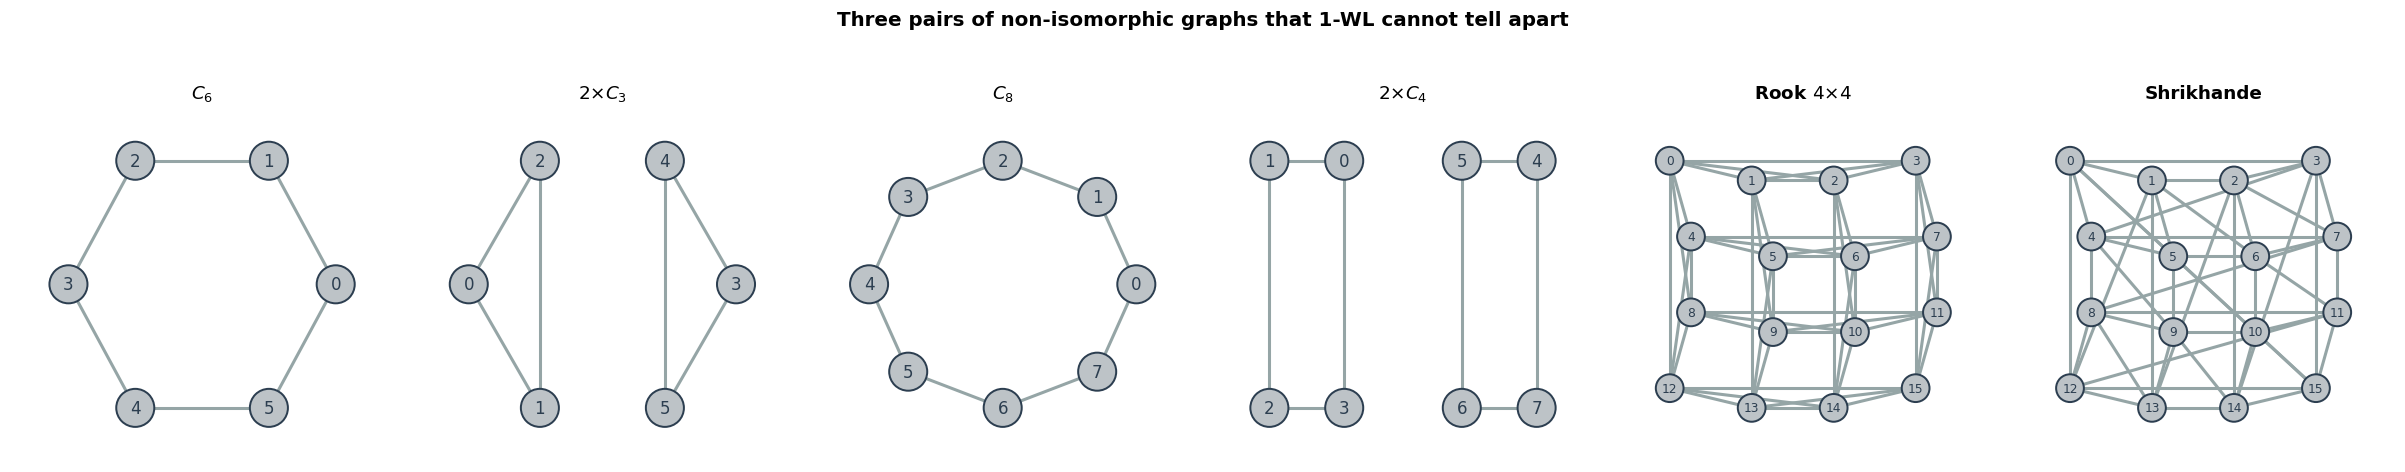

The last two are drawn on the same 4x4 grid. Both are 6-regular with 48 edges
and 32 triangles; only the wiring differs, and 1-WL cannot feel that difference.


In [26]:
# Two squares, drawn as two clearly separate components
POS_2C4 = {}
for offset, comp in [(-1.0, [0, 1, 2, 3]), (1.0, [4, 5, 6, 7])]:
    for i, n in enumerate(comp):
        ang = np.pi / 4 + 2 * np.pi * i / 4
        POS_2C4[n] = np.array([offset + 0.55 * np.cos(ang), 0.55 * np.sin(ang)])

# Both 16-node graphs on the SAME 4x4 grid, so the edge patterns are comparable.
# In both constructions integer node n corresponds to grid cell (n // 4, n % 4).
# The grid is gently warped so that no three nodes in a row stay collinear -- on a
# perfect grid the rook's long edges (0-2, 0-3) would be hidden underneath the short
# ones, making a 6-regular graph look 4-regular.
POS_GRID16 = {}
for n in range(16):
    r, c = n // 4, n % 4
    POS_GRID16[n] = np.array([c + 0.30 * np.sin(np.pi * r / 3.0),
                              -r - 0.30 * np.sin(np.pi * c / 3.0)])

fig, axes = plt.subplots(1, 6, figsize=(22, 4.1))
panels = [(C6, POS_C6, '$C_6$'),
          (TwoC3, POS_2C3, '$2{\\times}C_3$'),
          (nx.cycle_graph(8), nx.circular_layout(nx.cycle_graph(8)), '$C_8$'),
          (nx.disjoint_union(nx.cycle_graph(4), nx.cycle_graph(4)), POS_2C4, '$2{\\times}C_4$'),
          (rooks_graph_4x4(), POS_GRID16, 'Rook $4{\\times}4$'),
          (shrikhande_graph(), POS_GRID16, 'Shrikhande')]

for ax, (G, pos, title) in zip(axes, panels):
    big = G.number_of_nodes() > 8
    draw_graph(G, pos, ax, node_size=330 if big else 620, font_size=8 if big else 11,
               title=title)

plt.suptitle('Three pairs of non-isomorphic graphs that 1-WL cannot tell apart',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

print('The last two are drawn on the same 4x4 grid. Both are 6-regular with 48 edges')
print('and 32 triangles; only the wiring differs, and 1-WL cannot feel that difference.')

**The pattern.** 1-WL is blind to anything that requires *joining up* information about more than one
node at a time:

- **Regular graphs.** If every node has the same degree, round 1 produces one single color, and
  refinement is stuck there forever. All $d$-regular graphs on $n$ nodes look identical to 1-WL.
- **Counting substructures.** Triangles, cycles, cliques — detecting them means knowing whether two of
  *my* neighbors are adjacent to *each other*. A node's view is a tree, so it can never see that edge.
- **Distances and connectivity.** $C_8$ has node pairs at distance 4; in $2 \times C_4$ some pairs are
  not connected at all. Neither fact is expressible as a statement about individual unfolding trees.

In [27]:
# Regular graphs: refinement dies immediately
print('1-WL on d-regular graphs — the partition never refines:\n')
print(f"{'graph':>22s} {'n':>4s} {'regular':>8s} | distinct colors per round")
print('-' * 66)
for name, G in [('Cycle C6', C6), ('Two triangles', TwoC3), ('Petersen', nx.petersen_graph()),
                ('3-cube', nx.hypercube_graph(3)), ('Rook 4x4', rooks_graph_4x4()),
                ('Shrikhande', shrikhande_graph()), ('Karate (NOT regular)', nx.karate_club_graph())]:
    G = nx.convert_node_labels_to_integers(G)
    degs = {d for _, d in G.degree()}
    counts, _ = refinement_curve(G, 5)
    reg = f'{degs.pop()}-reg' if len(degs) == 1 else 'no'
    print(f'{name:>22s} {G.number_of_nodes():>4d} {reg:>8s} | {counts}')

1-WL on d-regular graphs — the partition never refines:

                 graph    n  regular | distinct colors per round
------------------------------------------------------------------
              Cycle C6    6    2-reg | [1, 1, 1, 1, 1, 1]
         Two triangles    6    2-reg | [1, 1, 1, 1, 1, 1]
              Petersen   10    3-reg | [1, 1, 1, 1, 1, 1]
                3-cube    8    3-reg | [1, 1, 1, 1, 1, 1]
              Rook 4x4   16    6-reg | [1, 1, 1, 1, 1, 1]
            Shrikhande   16    6-reg | [1, 1, 1, 1, 1, 1]
  Karate (NOT regular)   34       no | [1, 11, 27, 27, 27, 27]


---

## 6. Beyond 1-WL: The $k$-WL Hierarchy

### 6.1 The Idea: Color Tuples, Not Nodes

Every failure in §5.6 has the same root cause: colors live on **single nodes**, so relationships
*between* nodes are never recorded. The fix is direct — **give colors to $k$-tuples of nodes**.

With $k = 2$, the object colored is a *pair* $(v_1, v_2)$, and its initial color encodes whether the
two nodes are equal, adjacent, or non-adjacent. Adjacency is now part of the state being refined, so
triangles become visible: a triangle is just a pair whose two members share a common neighbor.

The **$k$-dimensional Folklore WL** ($k$-FWL) algorithm refines tuple colors as follows. Start from the
**atomic type** of each tuple — its ordered isomorphism type, i.e. the full pattern of equalities and
adjacencies among its entries. Then repeat:

$$c^{(\ell)}(\mathbf{v}) \;=\; \mathrm{HASH}\Big( c^{(\ell-1)}(\mathbf{v}), \;\; \big\{\!\!\big\{\, \big( c^{(\ell-1)}(\mathbf{v}[1 {\leftarrow} w]), \ldots, c^{(\ell-1)}(\mathbf{v}[k {\leftarrow} w]) \big) \;:\; w \in V \,\big\}\!\!\big\} \Big)$$

where $\mathbf{v}[i {\leftarrow} w]$ is $\mathbf{v}$ with its $i$-th entry replaced by $w$. So a tuple's
"neighbors" are the $k$ tuples obtained by substituting each position with some $w$ — and we collect
those $k$-vectors of colors over all $w \in V$ into a multiset.

**A note on naming**, because the literature uses two conventions:

| | colored object | relationship |
|---|---|---|
| **$k$-WL** (oblivious) | $k$-tuples, weaker update rule | 1-WL = 2-WL = color refinement |
| **$k$-FWL** (folklore) | $k$-tuples, update rule above | **$k$-FWL $\equiv$ $(k{+}1)$-WL** |

We implement $k$-FWL. So our `k=2` is as strong as 3-WL, and it is the first level that *strictly*
exceeds color refinement.

In [28]:
def atomic_type(G, t):
    """
    Ordered isomorphism type of the tuple t: the full pattern of which entries
    are equal and which are adjacent. This is the initial color in k-FWL.
    """
    k = len(t)
    equality  = tuple(tuple(int(t[i] == t[j]) for j in range(k)) for i in range(k))
    adjacency = tuple(tuple(int(G.has_edge(t[i], t[j])) for j in range(k)) for i in range(k))
    return ('atomic', equality, adjacency)


def k_fwl_refine(graphs, k=2, num_iterations=3):
    """
    k-dimensional Folklore Weisfeiler-Leman, run jointly over a list of graphs.

    k-FWL has the same distinguishing power as (k+1)-WL in the oblivious
    convention. Costs O(n^k) memory and O(n^(k+1)) time per round.

    Returns
    -------
    history : list of length num_iterations+1; history[l][i] is the dict
              {tuple: color_id} for graphs[i] after l rounds.
    """
    table, next_id = {}, 0

    def hash_to_color(signature):
        nonlocal next_id
        if signature not in table:
            table[signature] = next_id
            next_id += 1
        return table[signature]

    meta, colors = [], []
    for G in graphs:
        V = list(G.nodes())
        tuples = list(itertools.product(V, repeat=k))
        meta.append((V, tuples))
        colors.append({t: hash_to_color(atomic_type(G, t)) for t in tuples})

    history = [[dict(c) for c in colors]]
    for _ in range(num_iterations):
        new_colors = []
        for (V, tuples), c in zip(meta, colors):
            nc = {}
            for t in tuples:
                # For each w, the k-vector of colors of t with position i replaced by w
                neighbor_multiset = tuple(sorted(
                    tuple(c[t[:i] + (w,) + t[i + 1:]] for i in range(k)) for w in V))
                nc[t] = hash_to_color((c[t], neighbor_multiset))
            new_colors.append(nc)
        colors = new_colors
        history.append([dict(c) for c in colors])
    return history


def fwl_distinguishes(G1, G2, k=2, num_iterations=3):
    """True iff k-FWL separates the two graphs."""
    history = k_fwl_refine([G1, G2], k, num_iterations)
    return any(Counter(s[0].values()) != Counter(s[1].values()) for s in history)


print('k-FWL implemented.')
print(f'Atomic types in C6 for k=2: '
      f'{len({atomic_type(C6, t) for t in itertools.product(C6.nodes(), repeat=2)})} distinct '
      f'(equal pair / adjacent pair / non-adjacent pair)')

k-FWL implemented.
Atomic types in C6 for k=2: 3 distinct (equal pair / adjacent pair / non-adjacent pair)


### 6.2 2-FWL Cracks the Hexagon

In [29]:
print('Round-by-round number of distinct tuple colors:\n')
hist = k_fwl_refine([C6, TwoC3], k=2, num_iterations=3)
print(f"{'round':>6s} {'C6 colors':>11s} {'2xC3 colors':>13s} {'histograms equal?':>19s}")
print('-' * 54)
for l, step in enumerate(hist):
    h1, h2 = Counter(step[0].values()), Counter(step[1].values())
    print(f'{l:>6d} {len(h1):>11d} {len(h2):>13d} {str(h1 == h2):>19s}')

print(f'\n1-WL  distinguishes C6 from 2xC3: {wl_distinguishes(C6, TwoC3)}')
print(f'2-FWL distinguishes C6 from 2xC3: {fwl_distinguishes(C6, TwoC3)}')

Round-by-round number of distinct tuple colors:

 round   C6 colors   2xC3 colors   histograms equal?
------------------------------------------------------
     0           3             3                True
     1           4             3               False
     2           4             3               False
     3           4             3               False

1-WL  distinguishes C6 from 2xC3: False
2-FWL distinguishes C6 from 2xC3: True


### 6.3 Visualizing the Tuple Coloring

For $k = 2$ the coloring is a **matrix**: entry $(i, j)$ is the color of the pair $(i, j)$. Round 0 is
essentially the adjacency matrix with the diagonal marked. Watch the two graphs' matrices diverge.

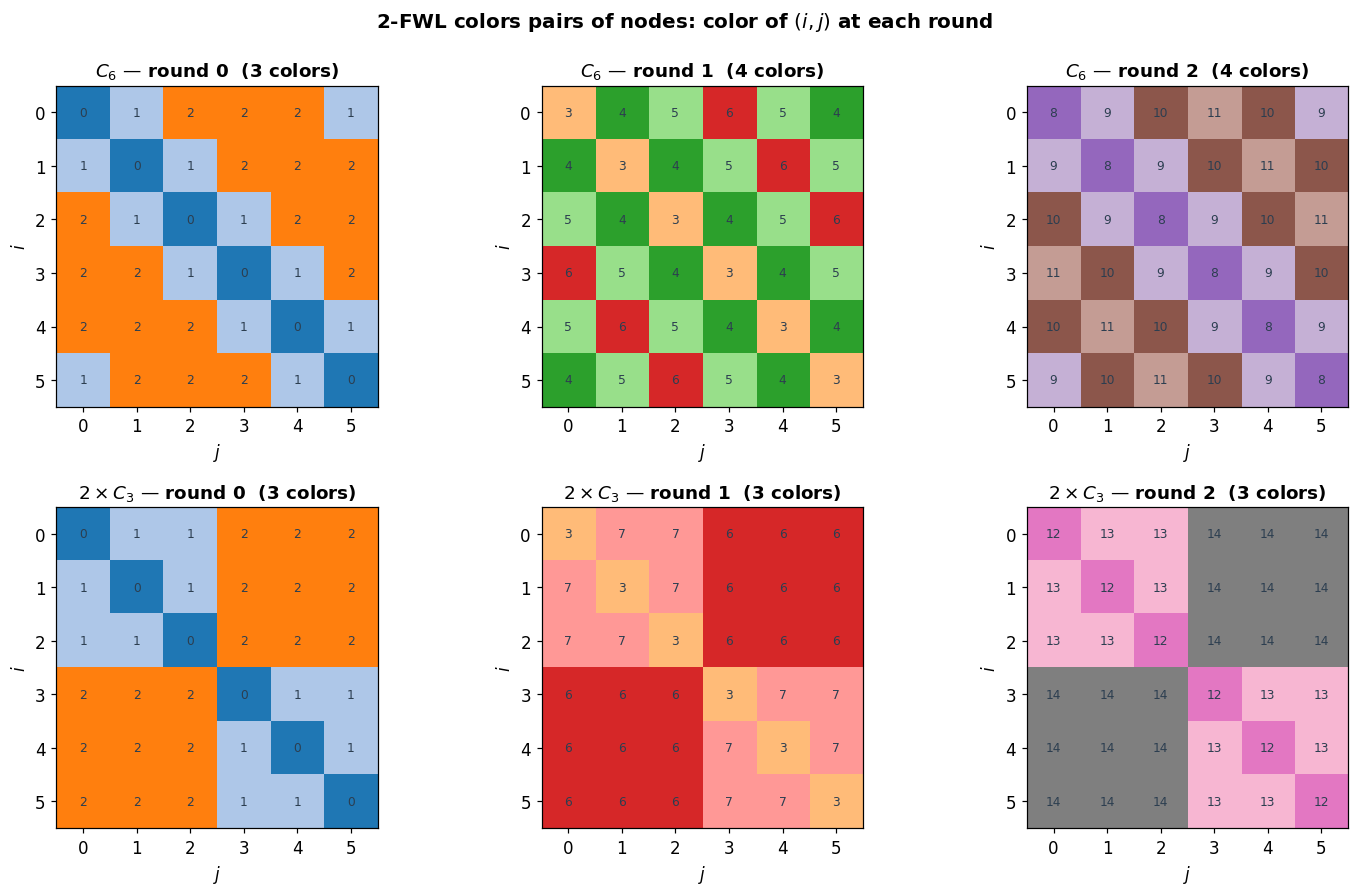

In [30]:
def tuple_color_matrix(colors, nodes):
    """Arrange a dict {(i,j): color} into an n x n matrix."""
    n = len(nodes)
    M = np.zeros((n, n), dtype=int)
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            M[i, j] = colors[(u, v)]
    return M


hist = k_fwl_refine([C6, TwoC3], k=2, num_iterations=2)
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.2))

for row, (name, G) in enumerate([('$C_6$', C6), ('$2\\times C_3$', TwoC3)]):
    nodes = list(G.nodes())
    for l in range(3):
        M = tuple_color_matrix(hist[l][row], nodes)
        ax = axes[row][l]
        ax.imshow(M, cmap='tab20', vmin=0, vmax=19, interpolation='none')
        for i in range(len(nodes)):
            for j in range(len(nodes)):
                ax.text(j, i, str(M[i, j]), ha='center', va='center', fontsize=8,
                        color=C_DARK)
        ax.set_title(f'{name} — round {l}  ({len(set(M.flatten()))} colors)')
        ax.set_xticks(range(len(nodes))); ax.set_yticks(range(len(nodes)))
        ax.set_xlabel('$j$'); ax.set_ylabel('$i$')

plt.suptitle('2-FWL colors pairs of nodes: color of $(i,j)$ at each round',
             fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout(); plt.show()

**Reading the matrices.** At round 0 both graphs show only 3 colors — *equal*, *adjacent*,
*non-adjacent* — and the two matrices are just permutations of each other. By round 1 they differ:
2-FWL has effectively measured, for each pair, **how many common neighbors it has**, which is exactly
the triangle information 1-WL could not reach. In $2 \times C_3$ every adjacent pair has a common
neighbor; in $C_6$ none does.

In [31]:
# What 2-FWL has effectively learned by round 1: common-neighbor counts per pair
print('For each of the 6 adjacent pairs (u,v), how many common neighbors does it have?\n')
for name, G in [('C6', C6), ('2 x C3', TwoC3)]:
    per_edge = [len(set(G.neighbors(u)) & set(G.neighbors(v))) for u, v in G.edges()]
    counts = Counter(per_edge)
    summary = ', '.join(f'{n} pair(s) with {c} common neighbor(s)'
                        for c, n in sorted(counts.items()))
    print(f'  {name:8s}: {per_edge}   ->  {summary}')

print('\nIn 2 x C3 every edge closes a triangle; in C6 no edge does. That distinction')
print('is a property of a *pair* of nodes, so coloring pairs detects it immediately,')
print('while coloring single nodes never can.')

For each of the 6 adjacent pairs (u,v), how many common neighbors does it have?

  C6      : [0, 0, 0, 0, 0, 0]   ->  6 pair(s) with 0 common neighbor(s)
  2 x C3  : [1, 1, 1, 1, 1, 1]   ->  6 pair(s) with 1 common neighbor(s)

In 2 x C3 every edge closes a triangle; in C6 no edge does. That distinction
is a property of a *pair* of nodes, so coloring pairs detects it immediately,
while coloring single nodes never can.


### 6.4 The Hierarchy Is Strict

Is 2-FWL enough? No — and we can prove it with an explicit pair. The **4×4 rook's graph** and the
**Shrikhande graph** are both strongly regular with parameters $(16, 6, 2, 2)$: 16 nodes, every node of
degree 6, every adjacent pair with exactly 2 common neighbors, every non-adjacent pair with exactly 2
common neighbors. Since those are exactly the quantities 2-FWL computes, it cannot separate them.

3-FWL colors *triples*, which is enough to notice the difference: in the rook's graph the neighborhood
of a node is two disjoint triangles, while in the Shrikhande graph it is a 6-cycle.

In [32]:
rook, shrik = rooks_graph_4x4(), shrikhande_graph()

print('Rook 4x4  vs  Shrikhande')
print('-' * 52)
print(f'  nodes                 : {rook.number_of_nodes()}, {shrik.number_of_nodes()}')
print(f'  edges                 : {rook.number_of_edges()}, {shrik.number_of_edges()}')
print(f'  degree sequence equal : '
      f'{sorted(d for _, d in rook.degree()) == sorted(d for _, d in shrik.degree())}')
print(f'  total triangles       : {sum(nx.triangles(rook).values()) // 3}, '
      f'{sum(nx.triangles(shrik).values()) // 3}')
print(f'  isomorphic            : {nx.is_isomorphic(rook, shrik)}')

print('\nLocal structure — the subgraph induced on one node\'s 6 neighbors:')
for name, G in [('Rook 4x4', rook), ('Shrikhande', shrik)]:
    sub = G.subgraph(list(G.neighbors(0)))
    print(f'  {name:11s}: {sub.number_of_edges()} edges, '
          f'{nx.number_connected_components(sub)} component(s) '
          f'-> {"two disjoint triangles" if nx.number_connected_components(sub) == 2 else "a single 6-cycle"}')

Rook 4x4  vs  Shrikhande
----------------------------------------------------
  nodes                 : 16, 16
  edges                 : 48, 48
  degree sequence equal : True
  total triangles       : 32, 32
  isomorphic            : False

Local structure — the subgraph induced on one node's 6 neighbors:
  Rook 4x4   : 6 edges, 2 component(s) -> two disjoint triangles
  Shrikhande : 6 edges, 1 component(s) -> a single 6-cycle


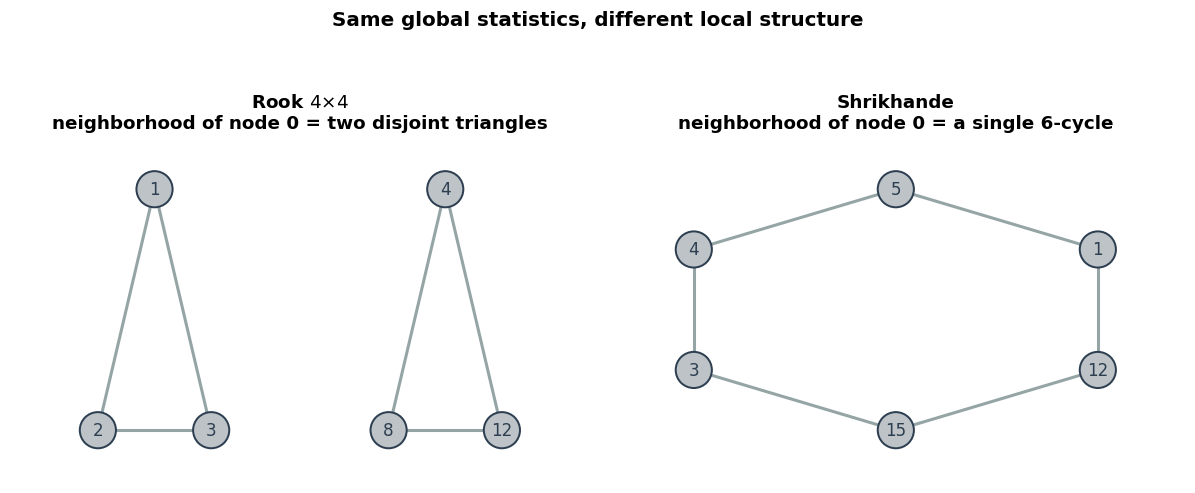

Both graphs are strongly regular with the same parameters (16, 6, 2, 2), so every
count 2-FWL can form is identical. The neighborhoods differ only in how those
2 common neighbors are connected to each other - which needs a third node to see.


In [33]:
def neighborhood_layout(sub):
    """
    Lay out a 2-regular subgraph according to its structure: two disjoint
    triangles side by side, or a single cycle drawn as a regular polygon.
    (A plain circular_layout would place cycle nodes out of order and the
    hexagon would look like a tangle.)
    """
    components = [sorted(c) for c in nx.connected_components(sub)]
    pos = {}
    if len(components) > 1:
        for offset, comp in zip(np.linspace(-1.0, 1.0, len(components)), components):
            for i, n in enumerate(comp):
                ang = np.pi / 2 + 2 * np.pi * i / len(comp)
                pos[n] = np.array([offset + 0.45 * np.cos(ang), 0.45 * np.sin(ang)])
    else:
        order = nx.cycle_basis(sub)[0]            # nodes in cycle order
        for i, n in enumerate(order):
            ang = np.pi / 2 + 2 * np.pi * i / len(order)
            pos[n] = np.array([np.cos(ang), np.sin(ang)])
    return pos


# The difference is entirely local: look at the subgraph induced on one node's neighbors.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (name, G) in zip(axes, [('Rook $4{\\times}4$', rooks_graph_4x4()),
                                ('Shrikhande', shrikhande_graph())]):
    sub = nx.Graph(G.subgraph(sorted(G.neighbors(0))))
    shape = ('two disjoint triangles' if nx.number_connected_components(sub) == 2
             else 'a single 6-cycle')
    draw_graph(sub, neighborhood_layout(sub), ax, node_size=560,
               title=f'{name}\nneighborhood of node 0 = {shape}')
plt.suptitle('Same global statistics, different local structure',
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout(); plt.show()

print('Both graphs are strongly regular with the same parameters (16, 6, 2, 2), so every')
print('count 2-FWL can form is identical. The neighborhoods differ only in how those')
print('2 common neighbors are connected to each other - which needs a third node to see.')

In [34]:
import time

print('Climbing the hierarchy on Rook 4x4 vs Shrikhande:\n')
print(f"{'test':>8s} {'equivalent to':>15s} {'tuples':>9s} {'distinguishes?':>16s} {'time':>8s}")
print('-' * 62)

t0 = time.time()
r1 = wl_distinguishes(rook, shrik, num_iterations=5)
print(f'{"1-WL":>8s} {"1-WL":>15s} {16:>9d} {str(r1):>16s} {time.time()-t0:>7.2f}s')

for k in [2, 3]:
    t0 = time.time()
    res = fwl_distinguishes(rook, shrik, k=k, num_iterations=2 if k == 3 else 3)
    print(f'{f"{k}-FWL":>8s} {f"{k+1}-WL":>15s} {16**k:>9d} {str(res):>16s} {time.time()-t0:>7.2f}s')

Climbing the hierarchy on Rook 4x4 vs Shrikhande:

    test   equivalent to    tuples   distinguishes?     time
--------------------------------------------------------------
    1-WL            1-WL        16            False    0.00s
   2-FWL            3-WL       256            False    0.02s


   3-FWL            4-WL      4096             True    0.24s


> **A strict hierarchy, verified end to end.**
>
> $$\text{MPNN} \preceq \underbrace{\text{1-WL}}_{\text{fails } C_6 / 2C_3} \prec \underbrace{\text{2-FWL}}_{\substack{\text{solves } C_6/2C_3 \\ \text{fails Rook/Shrikhande}}} \prec \underbrace{\text{3-FWL}}_{\text{solves Rook/Shrikhande}} \prec \cdots$$
>
> Each level is *strictly* stronger: for every $k$ there is a pair of graphs that $k$-FWL cannot
> separate but $(k{+}1)$-FWL can. The standard construction is the family of
> **Cai–Fürer–Immerman (CFI) graphs**, which shows no fixed $k$ suffices for graph isomorphism in
> general.

### 6.5 The Price of Power

The hierarchy's cost is brutal. $k$-FWL colors all $n^k$ tuples and, for each, scans all $n$
substitutions — $O(n^k)$ memory and $O(n^{k+1})$ time per round.

In [35]:
def human_bytes(n):
    unit = 'B'
    for u in ['KB', 'MB', 'GB', 'TB', 'PB', 'EB']:
        if n < 1024:
            break
        n, unit = n / 1024, u
    return f'{n:.1f} {unit}'


print(f"{'k':>3s} {'equivalent':>11s} {'tuples (n=100)':>16s} "
      f"{'tuples (n=10,000)':>27s} {'memory @ 4B each':>18s}")
print('-' * 81)
for k in [1, 2, 3, 4]:
    t100, t10k = 100 ** k, 10000 ** k
    label = '1-WL' if k == 1 else f'{k + 1}-WL'
    print(f'{k:>3d} {label:>11s} {t100:>16,d} {t10k:>27,d} {human_bytes(t10k * 4):>18s}')

print('\nEven k=2 is already impractical on a graph with 10k nodes, which is small by')
print('modern standards. This motivates the cheaper alternatives in the next section.')

  k  equivalent   tuples (n=100)           tuples (n=10,000)   memory @ 4B each
---------------------------------------------------------------------------------
  1        1-WL              100                      10,000            39.1 KB
  2        3-WL           10,000                 100,000,000           381.5 MB
  3        4-WL        1,000,000           1,000,000,000,000             3.6 TB
  4        5-WL      100,000,000      10,000,000,000,000,000            35.5 PB

Even k=2 is already impractical on a graph with 10k nodes, which is small by
modern standards. This motivates the cheaper alternatives in the next section.


---

## 7. Practical Routes to More Power

Nobody trains 3-FWL on a real dataset. Instead, practitioners buy expressive power more cheaply. Two
of the most common tricks are easy to demonstrate.

### 7.1 Structural Feature Augmentation

If a GNN cannot *compute* triangle counts, we can compute them ourselves and hand them over as input
features. Message passing is unchanged; only the input changes.

In [36]:
def augment_with_triangles(G):
    """Input features: [constant 1, number of triangles through v]."""
    tri = nx.triangles(G)
    return torch.tensor([[1.0, float(tri[v])] for v in sorted(G.nodes())])


print('Triangle counts per node:')
for name, G in [('C6', C6), ('2 x C3', TwoC3)]:
    print(f'  {name:8s}: {[nx.triangles(G)[v] for v in sorted(G.nodes())]}')

e1 = graph_embedding(C6,    X=augment_with_triangles(C6),    num_layers=2)
e2 = graph_embedding(TwoC3, X=augment_with_triangles(TwoC3), num_layers=2)
print(f'\nWith triangle features, max |emb(C6) - emb(2xC3)| = '
      f'{(e1 - e2).abs().max().item():.4f}   (was ~1e-15, i.e. zero)')

# The same fix at the WL level: start refinement from triangle counts
print(f'\n1-WL with uniform init          distinguishes: {wl_distinguishes(C6, TwoC3)}')
print(f'1-WL with triangle-count init   distinguishes: '
      f'{wl_distinguishes(C6, TwoC3, init_fn=lambda G, v: ("tri", nx.triangles(G)[v]))}')

Triangle counts per node:
  C6      : [0, 0, 0, 0, 0, 0]
  2 x C3  : [1, 1, 1, 1, 1, 1]

With triangle features, max |emb(C6) - emb(2xC3)| = 5.3684   (was ~1e-15, i.e. zero)

1-WL with uniform init          distinguishes: False
1-WL with triangle-count init   distinguishes: True


This works, and it is what many strong practical models do (cycle counts, spectral features,
substructure counts, shortest-path distances). But note what we did: we did not make the *GNN* more
expressive, we **moved the hard computation into preprocessing**. The features must be chosen in
advance, and they only help with the structures we thought to count.

### 7.2 Random Features: Power at the Cost of Invariance

A more drastic trick: give every node a unique random feature vector. Nodes are then trivially
distinguishable, so the 1-WL ceiling vanishes. But something valuable is lost.

In [37]:
print('Graph embeddings with random node features, across several draws:\n')
print(f"{'draw':>5s} {'||emb(C6) - emb(2xC3)||':>26s}")
print('-' * 33)
diffs = []
for draw in range(5):
    torch.manual_seed(100 + draw)
    X1, X2 = torch.randn(6, 8), torch.randn(6, 8)
    d = (graph_embedding(C6, X=X1, num_layers=2) -
         graph_embedding(TwoC3, X=X2, num_layers=2)).norm().item()
    diffs.append(d)
    print(f'{draw:>5d} {d:>26.4f}')

print(f'\nThe graphs are now separated (all differences > 0).')
print(f'But the value swings from {min(diffs):.3f} to {max(diffs):.3f} across draws —')
print('the model is no longer a deterministic function of the graph.')

Graph embeddings with random node features, across several draws:

 draw    ||emb(C6) - emb(2xC3)||
---------------------------------
    0                     5.8279
    1                     3.6191
    2                     7.0756
    3                     8.9902
    4                     4.6258

The graphs are now separated (all differences > 0).
But the value swings from 3.619 to 8.990 across draws —
the model is no longer a deterministic function of the graph.


In [38]:
# The deeper problem: the same graph gets different embeddings on different draws
print('Two random draws for the SAME graph (C6):\n')
embs = []
for draw in range(2):
    torch.manual_seed(200 + draw)
    embs.append(graph_embedding(C6, X=torch.randn(6, 8), num_layers=2))
print(f'  draw 0, first 4 dims: {np.round(embs[0].numpy()[:4], 4)}')
print(f'  draw 1, first 4 dims: {np.round(embs[1].numpy()[:4], 4)}')
print(f'  ||difference||      : {(embs[0] - embs[1]).norm().item():.4f}')
print('\n-> Permutation invariance is broken: isomorphic inputs can now get different')
print('   outputs. The model must *learn* to ignore the randomness, which costs sample')
print('   efficiency and hurts generalization to unseen graphs.')

Two random draws for the SAME graph (C6):

  draw 0, first 4 dims: [-2.0566 -0.3257  1.8674 -0.7461]
  draw 1, first 4 dims: [-2.4478 -1.1532  1.9286 -2.3169]
  ||difference||      : 5.3732

-> Permutation invariance is broken: isomorphic inputs can now get different
   outputs. The model must *learn* to ignore the randomness, which costs sample
   efficiency and hurts generalization to unseen graphs.


### 7.3 The Landscape of Approaches

| Approach | Idea | Power | Cost |
|---|---|---|---|
| **GCN / GraphSAGE (mean, max)** | message passing, non-injective agg | **< 1-WL** | $O(|E|)$ |
| **GIN** | sum aggregation + MLP | **= 1-WL** | $O(\|E\|)$ |
| **+ structural features** | precompute cycle/substructure counts | > 1-WL, task-dependent | preprocessing |
| **+ random / unique IDs** | break symmetry by fiat | very high, but **not invariant** | loses generalization |
| **$k$-GNN / higher-order** | message passing on $k$-tuples | $\approx k$-WL | $O(n^k)$ |
| **Subgraph GNNs** (ESAN, GNN-AK) | run a GNN on many node-deleted subgraphs | > 1-WL | $O(n) \times$ GNN |
| **Positional encodings** (Laplacian eigenvectors) | spectral coordinates as features | > 1-WL | eigendecomposition |

The practical sweet spot is almost always the middle rows: keep cheap message passing, and inject the
structural information the architecture provably cannot compute.

---

## 8. Summary

### 8.1 The Chain of Reasoning

Everything in this notebook follows one line of argument:

1. **A node's view is a tree.** Running $L$ message-passing layers means computing a function of the
   depth-$L$ **unfolding tree** of each node (§3). Cycles, and the fact that two tree copies are really
   the same node, are invisible.
2. **Same tree ⇒ same embedding.** Two nodes with identical unfolding trees get identical embeddings
   from *every* MPNN at *every* weight setting (§3.3).
3. **1-WL tracks exactly this.** Color refinement assigns equal colors precisely to nodes with equal
   unfolding trees — in polynomial time instead of exponential space (§4).
4. **So MPNN $\preceq$ 1-WL, with equality achievable.** The bound is tight: sum aggregation plus an
   MLP (GIN) reaches it; mean and max fall short because they are not injective on multisets (§5).
5. **Above 1-WL lies a strict hierarchy.** Coloring $k$-tuples instead of nodes gives $k$-FWL, strictly
   stronger at each level, at $O(n^k)$ cost (§6).
6. **In practice we cheat, carefully.** Feature augmentation and subgraph methods buy the missing
   structural information without paying $O(n^k)$ (§7).

### 8.2 What We Verified Numerically

In [39]:
print('=' * 72)
print('SUMMARY OF VERIFIED CLAIMS'.center(72))
print('=' * 72)

checks = []

# 1. No MPNN separates C6 from 2xC3
sep = any((graph_embedding(C6, agg=a, seed=s) - graph_embedding(TwoC3, agg=a, seed=s)
           ).abs().max().item() > TOL for a in ['sum', 'mean', 'max'] for s in range(4))
checks.append(('No MPNN separates C6 from 2xC3', not sep, True))

# 2. Their unfolding trees are identical
checks.append(('Their depth-3 unfolding trees are identical',
               tree_shape(unfolding_tree(C6, 0, 3), (0,)) ==
               tree_shape(unfolding_tree(TwoC3, 0, 3), (0,)), True))

# 3. 1-WL also fails, and so does networkx's implementation
checks.append(('1-WL also fails on that pair', not wl_distinguishes(C6, TwoC3), True))
checks.append(('networkx WL hash agrees',
               nx.weisfeiler_lehman_graph_hash(C6, iterations=4) ==
               nx.weisfeiler_lehman_graph_hash(TwoC3, iterations=4), True))

# 4. GNN partition == 1-WL partition
checks.append(('GIN partition == 1-WL partition on 8 graphs x 3 depths',
               all(compare_gnn_to_wl(G, L)[2] for _, G in test_graphs for L in [1, 2, 3]), True))

# 5. sum is injective where mean/max are not
SA, SB = torch.stack([red, blue]), torch.stack([red, red, blue, blue])
checks.append(('sum separates {r,b} from {r,r,b,b}',
               not torch.allclose(SA.sum(0), SB.sum(0)), True))
checks.append(('mean does NOT', torch.allclose(SA.mean(0), SB.mean(0)), True))
checks.append(('max does NOT',
               torch.allclose(SA.max(0).values, SB.max(0).values), True))

# 5b. the aggregator collapse is exact, inside a single graph
with torch.no_grad():
    _h = {a: MPNN(3, 32, 1, a, 0.1, seed=0)(X_agg, adjacency(G_agg)) for a in ['sum', 'mean', 'max']}
checks.append(('sum keeps all 3 star centers apart',
               all((_h['sum'][a] - _h['sum'][b]).abs().max().item() > TOL
                   for a, b in [(0, 3), (0, 8), (3, 8)]), True))
checks.append(('mean collapses the {r,b} / {r,r,b,b} centers',
               (_h['mean'][0] - _h['mean'][3]).abs().max().item() <= TOL, True))
checks.append(('max collapses all 3 centers',
               all((_h['max'][a] - _h['max'][b]).abs().max().item() <= TOL
                   for a, b in [(0, 3), (0, 8), (3, 8)]), True))

# 6. eps = 0 collapses cliques
Z0 = closed_neighborhood_sums(nx.complete_graph(4), torch.eye(4), 0.0)
Z1 = closed_neighborhood_sums(nx.complete_graph(4), torch.eye(4), 0.1)
checks.append(('eps=0 collapses all of K4 to one value',
               len({tuple(np.round(r, 6)) for r in Z0.numpy()}) == 1, True))
checks.append(('eps=0.1 keeps K4 nodes apart',
               len({tuple(np.round(r, 6)) for r in Z1.numpy()}) == 4, True))

# 7. The hierarchy is strict
checks.append(('2-FWL separates C6 from 2xC3 (1-WL could not)',
               fwl_distinguishes(C6, TwoC3), True))
checks.append(('2-FWL FAILS on Rook4x4 vs Shrikhande',
               not fwl_distinguishes(rook, shrik, k=2, num_iterations=3), True))
checks.append(('3-FWL separates Rook4x4 vs Shrikhande',
               fwl_distinguishes(rook, shrik, k=3, num_iterations=2), True))

# 8. Augmentation helps
checks.append(('Triangle features separate C6 from 2xC3',
               (graph_embedding(C6, X=augment_with_triangles(C6), num_layers=2) -
                graph_embedding(TwoC3, X=augment_with_triangles(TwoC3), num_layers=2)
                ).abs().max().item() > TOL, True))

for desc, got, want in checks:
    print(f'  [{"PASS" if got == want else "FAIL"}]  {desc}')
print('=' * 72)
print(f'  {sum(1 for _, g, w in checks if g == w)}/{len(checks)} claims verified')
print('=' * 72)

                       SUMMARY OF VERIFIED CLAIMS                       


  [PASS]  No MPNN separates C6 from 2xC3
  [PASS]  Their depth-3 unfolding trees are identical
  [PASS]  1-WL also fails on that pair
  [PASS]  networkx WL hash agrees
  [PASS]  GIN partition == 1-WL partition on 8 graphs x 3 depths
  [PASS]  sum separates {r,b} from {r,r,b,b}
  [PASS]  mean does NOT
  [PASS]  max does NOT
  [PASS]  sum keeps all 3 star centers apart
  [PASS]  mean collapses the {r,b} / {r,r,b,b} centers
  [PASS]  max collapses all 3 centers
  [PASS]  eps=0 collapses all of K4 to one value
  [PASS]  eps=0.1 keeps K4 nodes apart
  [PASS]  2-FWL separates C6 from 2xC3 (1-WL could not)
  [PASS]  2-FWL FAILS on Rook4x4 vs Shrikhande
  [PASS]  3-FWL separates Rook4x4 vs Shrikhande
  [PASS]  Triangle features separate C6 from 2xC3
  17/17 claims verified


### 8.3 The Big Picture

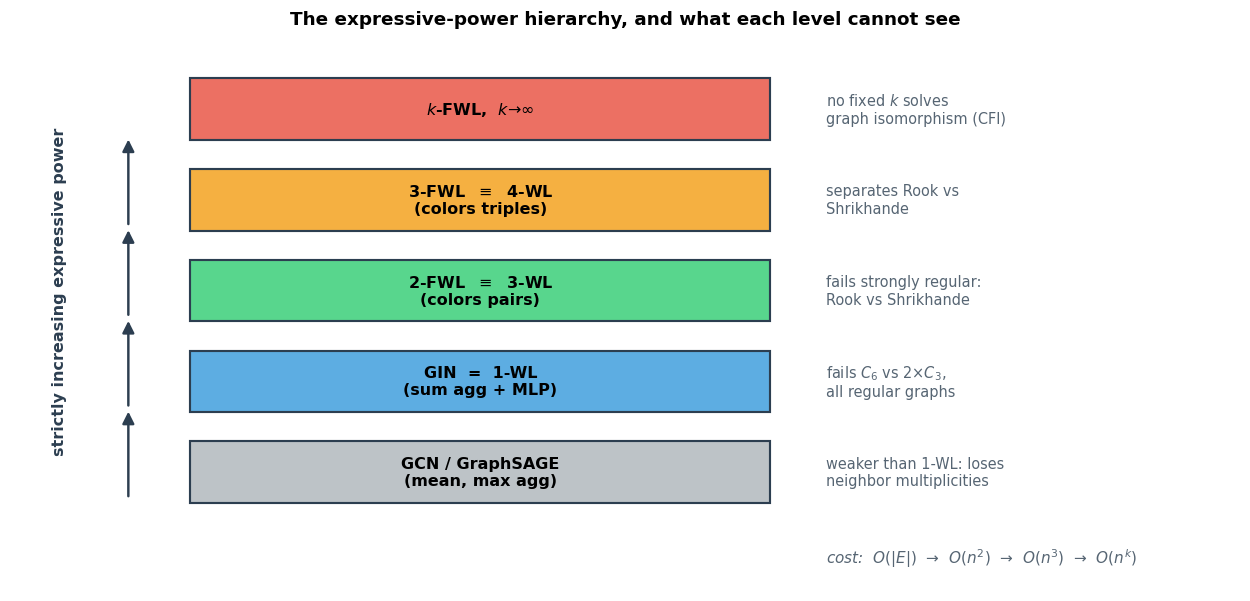

In [40]:
fig, ax = plt.subplots(figsize=(11.5, 5.6))

levels = [
    (0, 'GCN / GraphSAGE\n(mean, max agg)', '#BDC3C7', 'weaker than 1-WL: loses\nneighbor multiplicities'),
    (1, 'GIN  =  1-WL\n(sum agg + MLP)', '#5DADE2', 'fails $C_6$ vs $2{\\times}C_3$,\nall regular graphs'),
    (2, '2-FWL  $\\equiv$  3-WL\n(colors pairs)', '#58D68D', 'fails strongly regular:\nRook vs Shrikhande'),
    (3, '3-FWL  $\\equiv$  4-WL\n(colors triples)', '#F5B041', 'separates Rook vs\nShrikhande'),
    (4, '$k$-FWL,  $k \\to \\infty$', '#EC7063', 'no fixed $k$ solves\ngraph isomorphism (CFI)'),
]

for y, label, color, note in levels:
    ax.add_patch(plt.Rectangle((0, y - 0.34), 4.2, 0.68, facecolor=color,
                               edgecolor=C_DARK, linewidth=1.4, zorder=2))
    ax.text(2.1, y, label, ha='center', va='center', fontsize=10.5,
            fontweight='bold', zorder=3)
    ax.text(4.6, y, note, ha='left', va='center', fontsize=9.5, color='#566573')
    if y < 4:
        ax.add_patch(FancyArrowPatch((-0.45, y - 0.3), (-0.45, y + 0.7),
                                     arrowstyle='-|>', mutation_scale=16,
                                     color=C_DARK, linewidth=1.6))

ax.text(-0.95, 2, 'strictly increasing expressive power', rotation=90,
        ha='center', va='center', fontsize=10.5, fontweight='bold', color=C_DARK)
ax.text(4.6, -0.95, 'cost:  $O(|E|)$  →  $O(n^2)$  →  $O(n^3)$  →  $O(n^k)$',
        ha='left', va='center', fontsize=10, style='italic', color='#566573')

ax.set_xlim(-1.3, 7.6); ax.set_ylim(-1.3, 4.7)
ax.set_title('The expressive-power hierarchy, and what each level cannot see', pad=14)
ax.set_axis_off()
plt.tight_layout(); plt.show()

### 8.4 Exercises

1. **Unfolding trees.** Modify `unfolding_tree` so a node never sends a message back to the node it
   just received from (a "non-backtracking" GNN). Does this change which graphs can be distinguished?
   Test it on $C_6$ vs $2 \times C_3$.

2. **Your own hard pair.** Find two non-isomorphic graphs on 8 nodes that 1-WL cannot separate but that
   are *not* both regular. (Hint: 1-WL only needs the *histograms* to match, not the colorings.)

3. **Aggregator ablation.** Build a dataset of graph pairs and measure what fraction each of sum, mean
   and max can separate. Does the ordering match the theory in §5.3?

4. **Cycle counting.** Augment node features with counts of cycles of length 3, 4, 5, 6 and find a
   graph pair that *still* defeats the augmented model.

5. **Cost of k-FWL.** Time `k_fwl_refine` with $k = 2$ on random graphs with $n = 10, 20, 40, 80$.
   Fit the exponent and compare it with the predicted $O(n^{k+1})$ per round.

6. **From test to network.** `k_fwl_refine` is an *algorithm*, not a learnable model. Sketch a
   2-GNN: maintain a representation $h_{(u,v)}$ per pair, and define a message-passing rule over pairs
   that mirrors the 2-FWL update.

### 8.5 References

- Xu, Hu, Leskovec & Jegelka. *How Powerful are Graph Neural Networks?* ICLR 2019. — GIN, the 1-WL bound.
- Morris, Ritzert, Fey, Hamilton, Lenssen, Rattan & Grohe. *Weisfeiler and Leman Go Neural.* AAAI 2019. — $k$-GNNs.
- Weisfeiler & Leman. *A reduction of a graph to a canonical form.* 1968. — the original algorithm.
- Cai, Fürer & Immerman. *An optimal lower bound on the number of variables for graph identification.* 1992. — the CFI construction.
- Maron, Ben-Hamu, Serviansky & Lipman. *Provably Powerful Graph Networks.* NeurIPS 2019. — practical 3-WL-equivalent models.
- Sato. *A Survey on the Expressive Power of Graph Neural Networks.* 2020. — a broad overview.